In [1]:
15# -*- coding: utf-8 -*-
"""
╔══════════════════════════════════════════════════════════════════════════════╗
║  SISTEMA DE ALERTA TEMPRANA PARA LA DESERCIÓN ESTUDIANTIL (MLP)             ║
║  Universidad Continental — Proyecto de Inteligencia Artificial              ║
║                                                                            ║
║  Dataset: :contentReference[oaicite:0]{index=0}
║  Metodología: CRISP-ML(Q)                                                   ║
╚══════════════════════════════════════════════════════════════════════════════╝

🎯 OBJETIVO:
Predecir si un estudiante:
- Abandonará (Dropout)
- Continuará (Enrolled)
- Se graduará (Graduate)

🧠 MODELO:
Red Neuronal Artificial (MLP - Multilayer Perceptron)

⚙️ MEJORAS IMPLEMENTADAS:
✔ Uso de pipeline estructurado
✔ Escalado de datos
✔ Balanceo con SMOTE
✔ Explicabilidad con SHAP
✔ Guardado de modelo (.keras) y scaler (.pkl)
"""

# ==============================================================================
# ⚙️ CELDA 0 — INSTALACIÓN DE DEPENDENCIAS
# ==============================================================================

# Instala todas las librerías necesarias (solo la primera vez en Colab)
!pip install ucimlrepo scikit-learn imbalanced-learn tensorflow matplotlib seaborn pandas numpy shap joblib -q

print("✅ Librerías instaladas correctamente")


# ==============================================================================
# 📦 CELDA 0B — IMPORTACIONES
# ==============================================================================

# 🔇 Ignorar advertencias innecesarias
import warnings
warnings.filterwarnings('ignore')

# 📊 Manipulación de datos
import numpy as np
import pandas as pd

# 📈 Visualización
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# 💾 Guardado de modelos
import joblib

# 🔍 Explicabilidad del modelo
import shap

# 📥 Importar dataset desde UCI
from ucimlrepo import fetch_ucirepo

# 🤖 Scikit-learn (procesamiento y métricas)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    recall_score, precision_score, f1_score,
    confusion_matrix, classification_report,
    precision_recall_curve, auc, roc_auc_score
)

# ⚖️ Balanceo de datos (evita sesgos)
from imblearn.over_sampling import SMOTE

# 🧠 TensorFlow / Keras (Red Neuronal)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


# ==============================================================================
# 🎨 CONFIGURACIÓN VISUAL
# ==============================================================================

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

sns.set_palette("husl")


# ==============================================================================
# ✅ VERIFICACIÓN DE ENTORNO
# ==============================================================================

print(f"✅ TensorFlow versión: {tf.__version__}")
print("✅ Scikit-learn listo")
print("✅ Entorno preparado correctamente")



✅ Librerías instaladas correctamente
✅ TensorFlow versión: 2.20.0
✅ Scikit-learn listo
✅ Entorno preparado correctamente


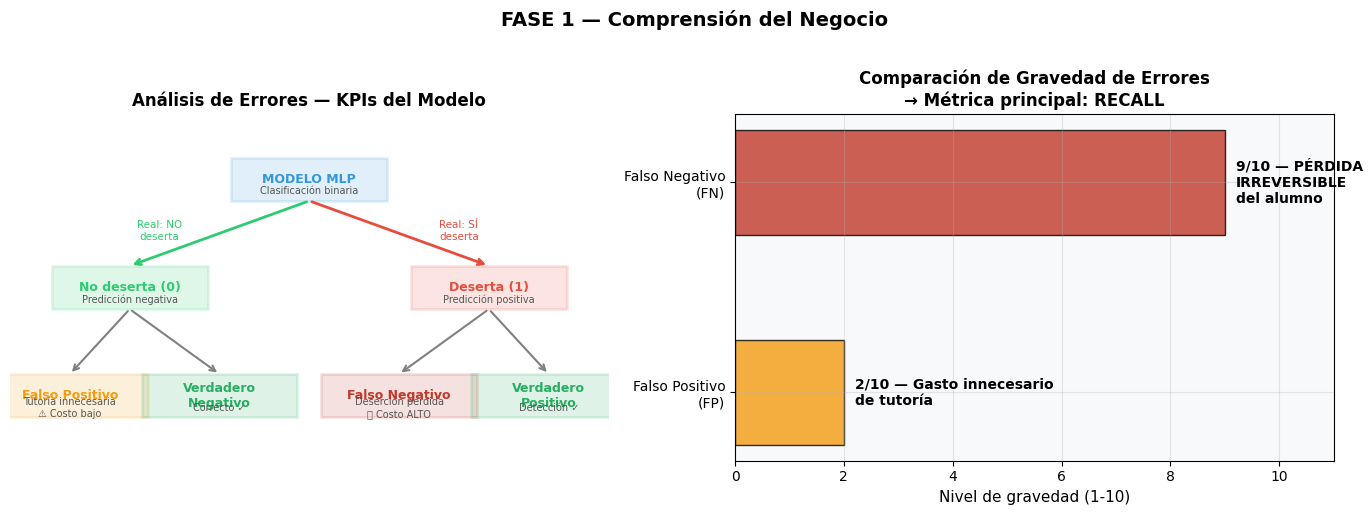

✅ Fase 1 completada — Diagrama guardado


In [2]:
# ==============================================================================
# ═══════════════════════════════════════════════════════════════════════════════
#  FASE 1 — COMPRENSIÓN DEL NEGOCIO (Business Understanding)
# ═══════════════════════════════════════════════════════════════════════════════
# ==============================================================================

"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
FASE 1 — COMPRENSIÓN DEL NEGOCIO
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

CONTEXTO
La Universidad Continental enfrenta una tasa de deserción del 15% en el
primer ciclo académico. El objetivo es construir un modelo de clasificación
binaria que identifique, de forma proactiva, a los estudiantes con alta
probabilidad de abandonar sus estudios.

TRADUCCIÓN AL LENGUAJE DE ML
  - Tipo de problema : Clasificación binaria supervisada
  - Variable objetivo: 'desercion'  →  1 = deserta,  0 = no deserta
  - Métrica principal: RECALL  (minimizar Falsos Negativos)

ANÁLISIS DE ERRORES — ¿Qué es más grave?
┌─────────────────┬──────────────────────────────────────────────┬─────────┐
│ Tipo de error   │ Consecuencia                                 │Gravedad │
├─────────────────┼──────────────────────────────────────────────┼─────────┤
│ Falso Positivo  │ Enviar tutoría a quien no la necesita        │  Baja   │
│ (FP)            │ → Gasto de recursos, pero alumno retenido    │         │
├─────────────────┼──────────────────────────────────────────────┼─────────┤
│ Falso Negativo  │ NO detectar a quien SÍ va a desertar         │  ALTA   │
│ (FN)            │ → Pérdida irreversible del alumno            │         │
└─────────────────┴──────────────────────────────────────────────┴─────────┘
→ Conclusión: RECALL es la métrica principal. Umbral recomendado: 0.7

CONSIDERACIONES ÉTICAS — Sesgo algorítmico
  ANTES del modelo  : No excluir variables socioeconómicas relevantes.
                      Sí excluir: raza, religión, etnia, origen.
  DURANTE el modelo : Regularización (Dropout) para no sobreajustar a
                      variables sensibles.
  DESPUÉS del modelo: Calcular Recall por quintiles socioeconómicos.
                      Usar SHAP para explicar predicciones individuales.
                      Comité de ética revisa alertas antes de enviarlas.
"""

# Celda visual — Diagrama de KPIs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo — Diagrama de flujo de errores
ax = axes[0]
ax.axis('off')
ax.set_xlim(0, 10)
ax.set_ylim(0, 8)

# Cajas del diagrama
for x, y_pos, color, label, sublabel in [
    (5, 6.5, '#3498db', 'MODELO MLP', 'Clasificación binaria'),
    (2, 4,   '#2ecc71', 'No deserta (0)', 'Predicción negativa'),
    (8, 4,   '#e74c3c', 'Deserta (1)',    'Predicción positiva'),
    (1, 1.5, '#f39c12', 'Falso Positivo', 'Tutoría innecesaria\n⚠ Costo bajo'),
    (3.5, 1.5, '#27ae60', 'Verdadero\nNegativo', 'Correcto ✓'),
    (6.5, 1.5, '#c0392b', 'Falso Negativo', 'Deserción perdida\n🚨 Costo ALTO'),
    (9, 1.5, '#27ae60', 'Verdadero\nPositivo', 'Detección ✓'),
]:
    ax.add_patch(plt.Rectangle((x-1.3, y_pos-0.5), 2.6, 1,
                                facecolor=color, alpha=0.15, edgecolor=color, linewidth=2))
    ax.text(x, y_pos, label, ha='center', va='center', fontsize=9, fontweight='bold', color=color)
    ax.text(x, y_pos-0.28, sublabel, ha='center', va='center', fontsize=7, color='#555')

ax.annotate('', xy=(2, 4.5), xytext=(5, 6),
            arrowprops=dict(arrowstyle='->', color='#2ecc71', lw=2))
ax.annotate('', xy=(8, 4.5), xytext=(5, 6),
            arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=2))
ax.annotate('', xy=(1, 2), xytext=(2, 3.5),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))
ax.annotate('', xy=(3.5, 2), xytext=(2, 3.5),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))
ax.annotate('', xy=(6.5, 2), xytext=(8, 3.5),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))
ax.annotate('', xy=(9, 2), xytext=(8, 3.5),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

ax.text(2.5, 5.1, 'Real: NO\ndeserta', ha='center', fontsize=7.5, color='#2ecc71')
ax.text(7.5, 5.1, 'Real: SÍ\ndeserta', ha='center', fontsize=7.5, color='#e74c3c')
ax.set_title('Análisis de Errores — KPIs del Modelo', fontweight='bold', fontsize=12)

# Panel derecho — Gravedad comparativa
ax2 = axes[1]
categorias = ['Falso Positivo\n(FP)', 'Falso Negativo\n(FN)']
costos = [2, 9]
colores = ['#f39c12', '#c0392b']
bars = ax2.barh(categorias, costos, color=colores, alpha=0.8, edgecolor='black', height=0.5)
ax2.set_xlim(0, 11)
ax2.set_xlabel('Nivel de gravedad (1-10)', fontsize=11)
ax2.set_title('Comparación de Gravedad de Errores\n→ Métrica principal: RECALL', fontweight='bold', fontsize=12)
for bar, val, txt in zip(bars, costos, ['Gasto innecesario\nde tutoría', 'PÉRDIDA\nIRREVERSIBLE\ndel alumno']):
    ax2.text(val + 0.2, bar.get_y() + bar.get_height()/2,
             f'{val}/10 — {txt}', va='center', fontsize=10, fontweight='bold')

plt.suptitle('FASE 1 — Comprensión del Negocio', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fase1_business_understanding.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Fase 1 completada — Diagrama guardado")

📥 Cargando dataset UCI #697...

📊 INFORMACIÓN GENERAL DEL DATASET
   Total de estudiantes : 4,424
   Total de variables   : 38

🎯 DISTRIBUCIÓN DE LA VARIABLE OBJETIVO:
   Graduate  : 2209 (49.9%) ████████████████
   Dropout   : 1421 (32.1%) ██████████
   Enrolled  :  794 (17.9%) █████

   → Tasa de deserción efectiva: 32.1%
   → Accuracy base (predecir siempre 0): 67.9%

📋 ESTADÍSTICAS DESCRIPTIVAS (primeras 8 variables):
       Marital Status  Application mode  Application order   Course  Daytime/evening attendance  Previous qualification  Previous qualification (grade)  Nacionality  Mother's qualification  Father's qualification  Mother's occupation  Father's occupation  Admission grade  Displaced  Educational special needs   Debtor  Tuition fees up to date   Gender  Scholarship holder  Age at enrollment  International  Curricular units 1st sem (credited)  Curricular units 1st sem (enrolled)  Curricular units 1st sem (evaluations)  Curricular units 1st sem (approved)  Curricular unit

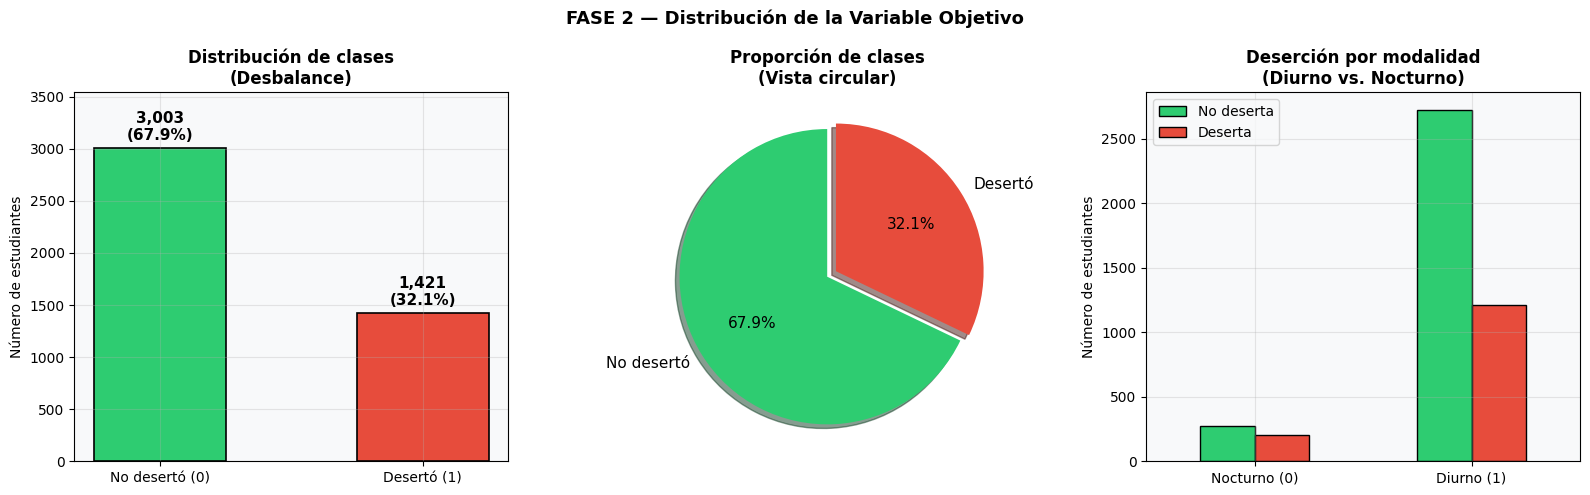

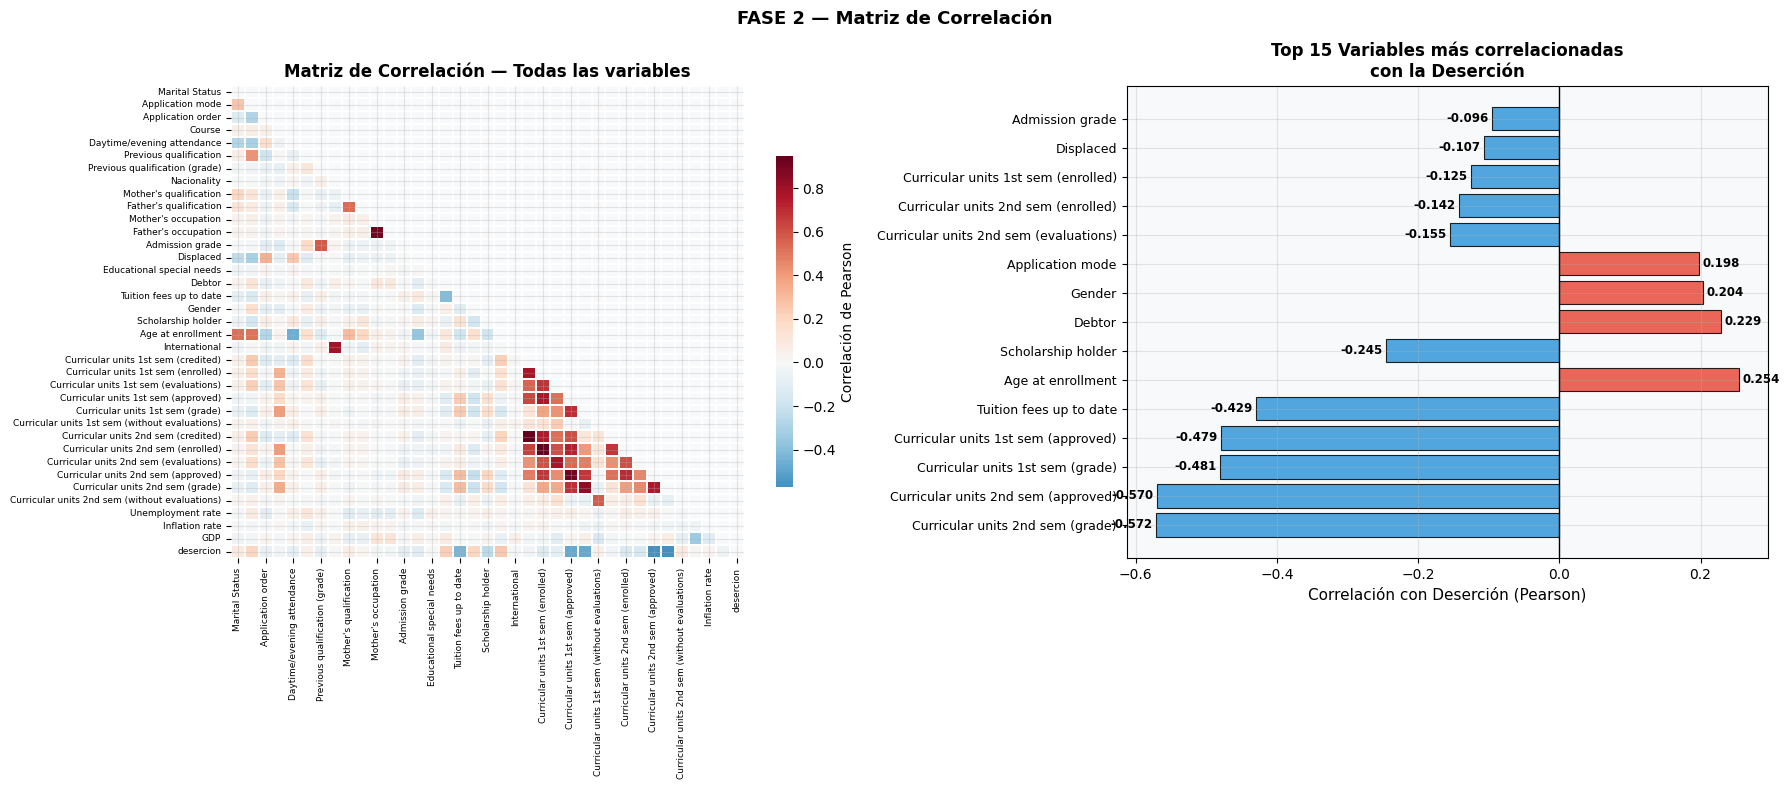

✅ Matriz de correlación guardada

📈 TOP 5 variables más correlacionadas con deserción:
Curricular units 2nd sem (grade)      -0.571792
Curricular units 2nd sem (approved)   -0.569500
Curricular units 1st sem (grade)      -0.480669
Curricular units 1st sem (approved)   -0.479112
Tuition fees up to date               -0.429149

📊 ANÁLISIS DE OUTLIERS (método IQR):
   Curricular units 1st sem (grade)        :  726 outliers (16.4%)
   Curricular units 2nd sem (grade)        :  877 outliers (19.8%)
   Curricular units 1st sem (approved)     :  180 outliers (4.1%)
   Curricular units 2nd sem (approved)     :   44 outliers (1.0%)
   Age at enrollment                       :  441 outliers (10.0%)
   Unemployment rate                       :    0 outliers (0.0%)


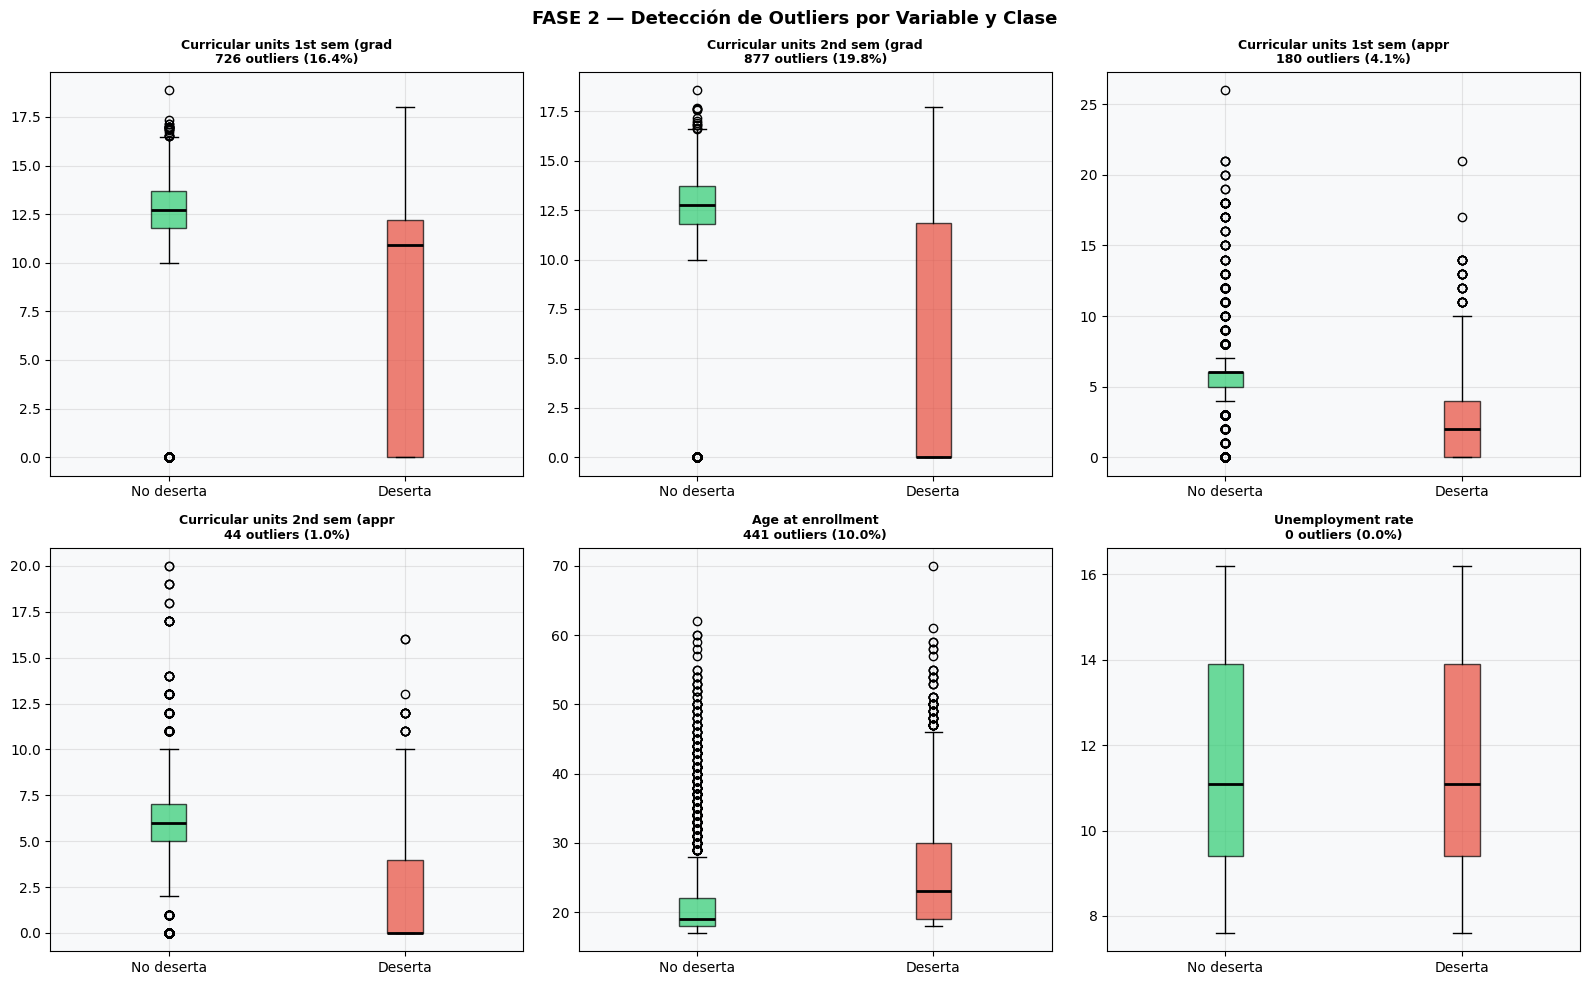


✅ Fase 2 completada


In [3]:
# ==============================================================================
# ═══════════════════════════════════════════════════════════════════════════════
#  FASE 2 — COMPRENSIÓN DE LOS DATOS (Data Understanding)
# ═══════════════════════════════════════════════════════════════════════════════
# ==============================================================================

# ── Celda 2.1 — Carga del dataset ──────────────────────────────────────────

print("📥 Cargando dataset UCI #697...")
datos = fetch_ucirepo(id=697)
X_raw = datos.data.features
y_raw = datos.data.targets
df = pd.concat([X_raw, y_raw], axis=1)

# Variable objetivo binaria: 1=Dropout, 0=Graduate/Enrolled
df['desercion'] = (df['Target'] == 'Dropout').astype(int)

print(f"\n📊 INFORMACIÓN GENERAL DEL DATASET")
print(f"   Total de estudiantes : {len(df):,}")
print(f"   Total de variables   : {len(df.columns)}")
print(f"\n🎯 DISTRIBUCIÓN DE LA VARIABLE OBJETIVO:")
vc = df['Target'].value_counts()
for clase, n in vc.items():
    pct = n / len(df) * 100
    barra = '█' * int(pct / 3)
    print(f"   {clase:10s}: {n:4d} ({pct:.1f}%) {barra}")

print(f"\n   → Tasa de deserción efectiva: {df['desercion'].mean()*100:.1f}%")
print(f"   → Accuracy base (predecir siempre 0): {(1-df['desercion'].mean())*100:.1f}%")

# ── Celda 2.2 — Estadísticas descriptivas ──────────────────────────────────

print("\n📋 ESTADÍSTICAS DESCRIPTIVAS (primeras 8 variables):")
print(df.describe().round(2).to_string())

# ── Celda 2.3 — Verificación de variables clave ────────────────────────────

print("\n🔍 VERIFICACIÓN DE VARIABLES CLAVE POR CATEGORÍA")
categorias_vars = {
    'Académicas': [
        'Curricular units 1st sem (grade)',
        'Curricular units 2nd sem (grade)',
        'Curricular units 1st sem (approved)',
        'Curricular units 2nd sem (approved)',
        'Curricular units 1st sem (enrolled)',
        'Curricular units 2nd sem (enrolled)',
    ],
    'Comportamentales': [
        'Daytime/evening attendance',
        'Curricular units 1st sem (evaluations)',
        'Curricular units 2nd sem (evaluations)',
        'Curricular units 1st sem (without evaluations)',
    ],
    'Socioeconómicas': [
        'Debtor',
        'Tuition fees up to date',
        'Scholarship holder',
        "Mother's qualification",
        "Father's qualification",
        'Unemployment rate',
        'Inflation rate',
        'GDP',
        'Age at enrollment',
        'Gender',
    ]
}

for categoria, vars_lista in categorias_vars.items():
    print(f"\n   [{categoria}]")
    for var in vars_lista:
        estado = '✅' if var in df.columns else '❌'
        print(f"     {estado} {var}")

# ── Celda 2.4 — Valores nulos ───────────────────────────────────────────────

print("\n🔍 ANÁLISIS DE VALORES NULOS:")
nulos = df.isnull().sum()
nulos_presentes = nulos[nulos > 0]
if len(nulos_presentes) == 0:
    print("   ✅ No hay valores nulos. Dataset completamente limpio.")
else:
    print(nulos_presentes)

# ── Celda 2.5 — Distribución de clases ────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Gráfico 1 — Distribución general
colores_bar = ['#2ecc71', '#e74c3c']
conteos = df['desercion'].value_counts().sort_index()
bars = axes[0].bar(['No desertó (0)', 'Desertó (1)'], conteos.values,
                    color=colores_bar, edgecolor='black', linewidth=1.2, width=0.5)
for bar, val in zip(bars, conteos.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[0].set_title('Distribución de clases\n(Desbalance)', fontweight='bold')
axes[0].set_ylabel('Número de estudiantes')
axes[0].set_ylim(0, max(conteos.values) * 1.18)

# Gráfico 2 — Pie chart
axes[1].pie(conteos.values, labels=['No desertó', 'Desertó'],
             colors=colores_bar, autopct='%1.1f%%', startangle=90,
             explode=(0, 0.07), shadow=True, textprops={'fontsize': 11})
axes[1].set_title('Proporción de clases\n(Vista circular)', fontweight='bold')

# Gráfico 3 — Deserción por modalidad (diurno/nocturno)
if 'Daytime/evening attendance' in df.columns:
    pivot = df.groupby(['Daytime/evening attendance', 'desercion']).size().unstack(fill_value=0)
    pivot.index = ['Nocturno (0)', 'Diurno (1)']
    pivot.columns = ['No deserta', 'Deserta']
    pivot.plot(kind='bar', ax=axes[2], color=['#2ecc71', '#e74c3c'],
               edgecolor='black', rot=0)
    axes[2].set_title('Deserción por modalidad\n(Diurno vs. Nocturno)', fontweight='bold')
    axes[2].set_ylabel('Número de estudiantes')
    axes[2].legend()

plt.suptitle('FASE 2 — Distribución de la Variable Objetivo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fase2_distribucion_clases.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Celda 2.6 — Matriz de correlación ──────────────────────────────────────

columnas_numericas = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[columnas_numericas].corr()

# Top correlaciones con la variable objetivo
corr_target = (corr_matrix['desercion']
               .drop('desercion')
               .sort_values(key=abs, ascending=False)
               .head(15))

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Heatmap completo (triangular inferior)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0,
            annot=False, linewidths=0.3,
            cbar_kws={"shrink": 0.7, "label": "Correlación de Pearson"},
            ax=axes[0])
axes[0].set_title('Matriz de Correlación — Todas las variables',
                   fontweight='bold', fontsize=12)
axes[0].tick_params(axis='x', rotation=90, labelsize=6.5)
axes[0].tick_params(axis='y', labelsize=6.5)

# Top 15 correlaciones con deserción
colores_corr = ['#e74c3c' if v > 0 else '#3498db' for v in corr_target.values]
bars = axes[1].barh(range(len(corr_target)), corr_target.values,
                     color=colores_corr, alpha=0.85, edgecolor='black', linewidth=0.8)
axes[1].set_yticks(range(len(corr_target)))
axes[1].set_yticklabels(corr_target.index, fontsize=9)
axes[1].axvline(x=0, color='black', linewidth=1, linestyle='-')
axes[1].set_xlabel('Correlación con Deserción (Pearson)', fontsize=11)
axes[1].set_title('Top 15 Variables más correlacionadas\ncon la Deserción', fontweight='bold', fontsize=12)

for bar, val in zip(bars, corr_target.values):
    axes[1].text(val + (0.005 if val >= 0 else -0.005),
                 bar.get_y() + bar.get_height() / 2,
                 f'{val:.3f}', va='center',
                 ha='left' if val >= 0 else 'right', fontsize=8.5, fontweight='bold')

plt.suptitle('FASE 2 — Matriz de Correlación', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fase2_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Matriz de correlación guardada")
print(f"\n📈 TOP 5 variables más correlacionadas con deserción:")
print(corr_target.head(5).to_string())

# ── Celda 2.7 — Detección de outliers ──────────────────────────────────────

key_vars = [
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (grade)',
    'Curricular units 1st sem (approved)',
    'Curricular units 2nd sem (approved)',
    'Age at enrollment',
    'Unemployment rate',
]
key_vars = [v for v in key_vars if v in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

def contar_outliers_iqr(serie):
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR = Q3 - Q1
    return ((serie < Q1 - 1.5*IQR) | (serie > Q3 + 1.5*IQR)).sum()

print("\n📊 ANÁLISIS DE OUTLIERS (método IQR):")
for i, var in enumerate(key_vars):
    n_out = contar_outliers_iqr(df[var])
    pct = n_out / len(df) * 100

    # Boxplot por clase de deserción
    datos_plot = [df[df['desercion']==0][var].dropna(),
                  df[df['desercion']==1][var].dropna()]
    bp = axes[i].boxplot(datos_plot, patch_artist=True, notch=False,
                          labels=['No deserta', 'Deserta'],
                          boxprops=dict(alpha=0.7))
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')
    for median in bp['medians']:
        median.set_color('black')
        median.set_linewidth(2)

    axes[i].set_title(f'{var[:30]}\n{n_out} outliers ({pct:.1f}%)',
                       fontsize=9, fontweight='bold')
    print(f"   {var[:40]:40s}: {n_out:4d} outliers ({pct:.1f}%)")

for j in range(len(key_vars), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('FASE 2 — Detección de Outliers por Variable y Clase',
              fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fase2_outliers.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Fase 2 completada")

FASE 3: PREPARACIÓN DE DATOS

📥 Cargando dataset UCI #697...
✅ Dataset cargado: 4424 estudiantes, 38 variables
   Tasa de deserción: 32.1%

TAREA 1: IMPUTACIÓN
✅ No hay valores nulos en el dataset. No fue necesario imputar.

TAREA 2: FEATURE ENGINEERING
✅ Nuevas variables creadas:
   - tasa_variacion_promedio (cambio de rendimiento entre semestres)
   - porcentaje_aprobados_1er (eficiencia académica 1er semestre)
   - porcentaje_aprobados_2do (eficiencia académica 2do semestre)

📊 Estadísticas de las nuevas variables:
   tasa_variacion_promedio: media=-0.41, std=2.89
   porcentaje_aprobados_1er: media=0.70, std=0.36
   porcentaje_aprobados_2do: media=0.66, std=0.38

SEPARACIÓN DE X e y
✅ Nombres de features guardados: 39 variables
📋 Las primeras 5: ['Marital Status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance']
Variables predictoras (X): 39 columnas
Variable objetivo (y): desercion
Total de estudiantes: 4424
Tasa de deserción: 32.1%

TAREA 3: ESTANDA

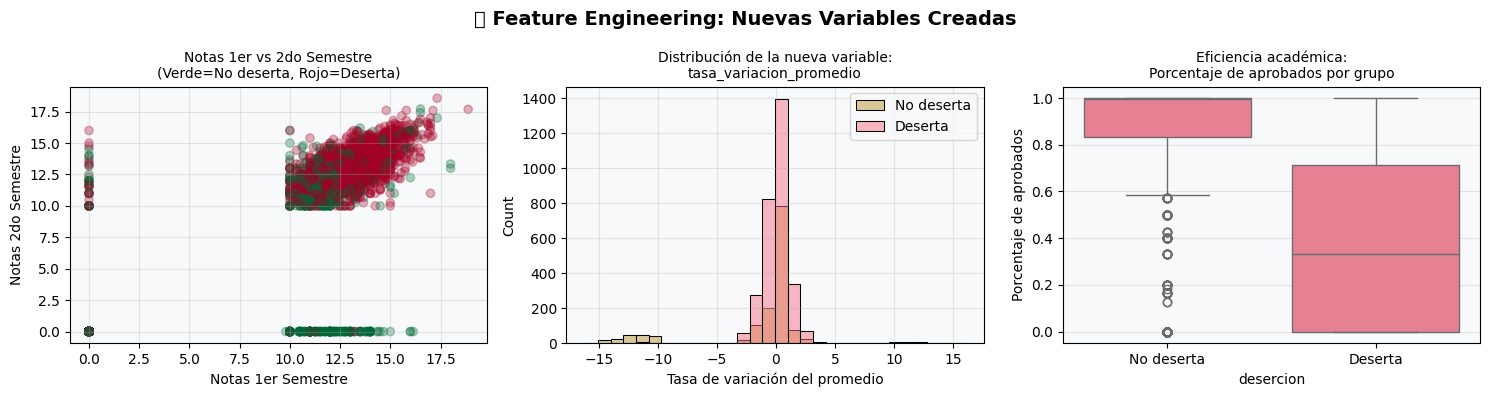

✅ Gráfico guardado: feature_engineering_fase3.png


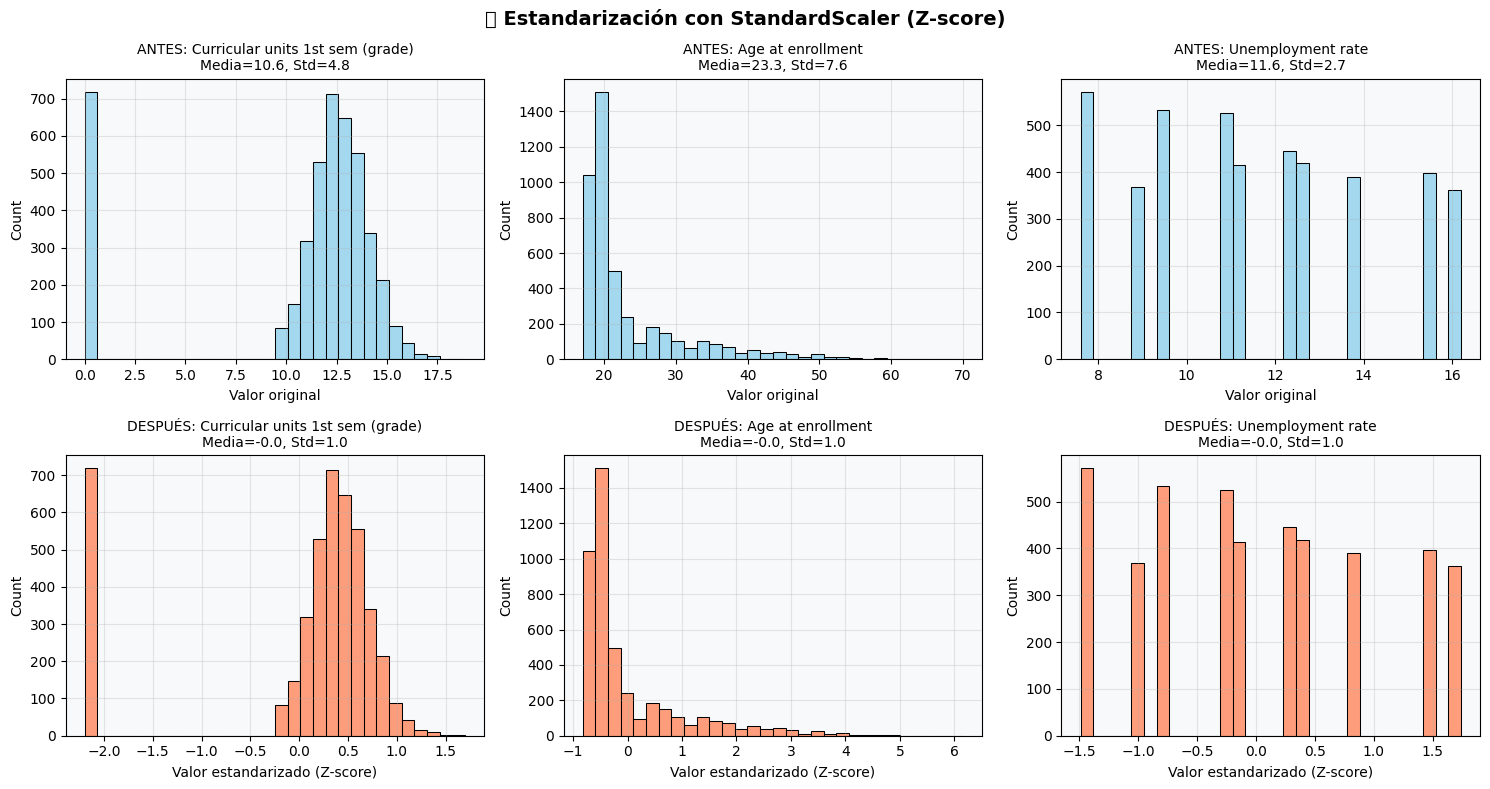

✅ Gráfico guardado: estandarizacion_fase3.png

📌 Interpretación:
   - ANTES: Cada variable tiene su propia escala (medias y desviaciones diferentes)
   - DESPUÉS: Todas las variables tienen media=0 y desviación=1


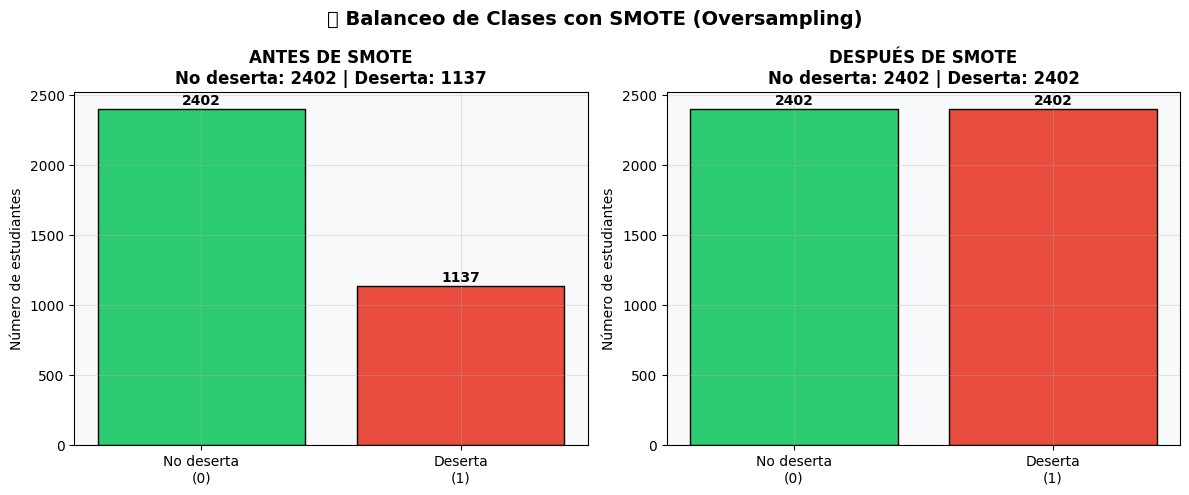

✅ Gráfico guardado: smote_balanceo_fase3.png

📌 Interpretación:
   - ANTES: Clase minoritaria (deserta) tiene menos muestras
   - DESPUÉS: SMOTE creó muestras sintéticas de la clase minoritaria

RESUMEN FASE 3: PREPARACIÓN DE DATOS

┌─────────────────────────────────────────────────────────────────────────────┐
│ TAREA                    │ LO QUE SE HIZO                                    │
├──────────────────────────┼──────────────────────────────────────────────────┤
│ 1. IMPUTACIÓN            │ ✅ No hay valores nulos. Dataset limpio           │
│ 2. FEATURE ENGINEERING   │ ✅ 3 nuevas variables creadas                     │
│ 3. ESTANDARIZACIÓN       │ ✅ StandardScaler (Z-score) aplicado              │
│ 4. BALANCEO DE CLASES    │ ✅ SMOTE aplicado (clases balanceadas 50%-50%)    │
└──────────────────────────┴──────────────────────────────────────────────────┘


📊 FORMA FINAL DE LOS DATOS:
   X_train_balanceado: (4804, 39)
   y_train_balanceado: (4804,)
   X_test: (885, 39)
   y_test:

In [4]:
# -*- coding: utf-8 -*-
"""
╔══════════════════════════════════════════════════════════════════════════════╗
║  FASE 3: PREPARACIÓN DE DATOS - Universidad Continental                     ║
║  Imputación | Feature Engineering | Estandarización | SMOTE | Gráficos      ║
╚══════════════════════════════════════════════════════════════════════════════╝
"""

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import joblib

print("="*60)
print("FASE 3: PREPARACIÓN DE DATOS")
print("="*60)

# ==============================================================================
# CARGA DE DATOS
# ==============================================================================

print("\n📥 Cargando dataset UCI #697...")
datos = fetch_ucirepo(id=697)
X = datos.data.features
y = datos.data.targets
df = pd.concat([X, y], axis=1)
df['desercion'] = (df['Target'] == 'Dropout').astype(int)

print(f"✅ Dataset cargado: {df.shape[0]} estudiantes, {df.shape[1]} variables")
print(f"   Tasa de deserción: {df['desercion'].mean()*100:.1f}%")

# ==============================================================================
# TAREA 1: IMPUTACIÓN (Manejo de valores nulos)
# ==============================================================================

print("\n" + "="*60)
print("TAREA 1: IMPUTACIÓN")
print("="*60)

nulos = df.isnull().sum()
nulos_presentes = nulos[nulos > 0]

if len(nulos_presentes) > 0:
    print("⚠️ Se encontraron valores nulos:")
    print(nulos_presentes)
    from sklearn.impute import SimpleImputer
    imputador = SimpleImputer(strategy='median')
    columnas_numericas = df.select_dtypes(include=[np.number]).columns
    df[columnas_numericas] = imputador.fit_transform(df[columnas_numericas])
    print("✅ Valores nulos imputados con la mediana")
else:
    print("✅ No hay valores nulos en el dataset. No fue necesario imputar.")

# ==============================================================================
# TAREA 2: FEATURE ENGINEERING (Creación de nuevas variables)
# ==============================================================================

print("\n" + "="*60)
print("TAREA 2: FEATURE ENGINEERING")
print("="*60)

# 1. Tasa de variación del promedio (tal como pide el ejemplo)
df['tasa_variacion_promedio'] = df['Curricular units 2nd sem (grade)'] - df['Curricular units 1st sem (grade)']

# 2. Porcentaje de créditos aprobados en primer semestre
df['porcentaje_aprobados_1er'] = df['Curricular units 1st sem (approved)'] / (df['Curricular units 1st sem (enrolled)'] + 0.01)

# 3. Porcentaje de créditos aprobados en segundo semestre
df['porcentaje_aprobados_2do'] = df['Curricular units 2nd sem (approved)'] / (df['Curricular units 2nd sem (enrolled)'] + 0.01)

print("✅ Nuevas variables creadas:")
print("   - tasa_variacion_promedio (cambio de rendimiento entre semestres)")
print("   - porcentaje_aprobados_1er (eficiencia académica 1er semestre)")
print("   - porcentaje_aprobados_2do (eficiencia académica 2do semestre)")

print("\n📊 Estadísticas de las nuevas variables:")
print(f"   tasa_variacion_promedio: media={df['tasa_variacion_promedio'].mean():.2f}, std={df['tasa_variacion_promedio'].std():.2f}")
print(f"   porcentaje_aprobados_1er: media={df['porcentaje_aprobados_1er'].mean():.2f}, std={df['porcentaje_aprobados_1er'].std():.2f}")
print(f"   porcentaje_aprobados_2do: media={df['porcentaje_aprobados_2do'].mean():.2f}, std={df['porcentaje_aprobados_2do'].std():.2f}")

# ==============================================================================
# SEPARACIÓN DE X e y
# ==============================================================================

print("\n" + "="*60)
print("SEPARACIÓN DE X e y")
print("="*60)

columnas_numericas = df.select_dtypes(include=[np.number]).columns
columnas_features = [col for col in columnas_numericas if col not in ['Target', 'desercion']]

X = df[columnas_features].copy()
y = df['desercion'].copy()

# ==============================================================================
# GUARDAR NOMBRES DE FEATURES (AÑADIR ESTO)
# ==============================================================================

# Guardar los nombres de las features para usarlos en despliegue
joblib.dump(columnas_features, 'features_names.pkl')
print(f"✅ Nombres de features guardados: {len(columnas_features)} variables")
print(f"📋 Las primeras 5: {columnas_features[:5]}")

print(f"Variables predictoras (X): {X.shape[1]} columnas")
print(f"Variable objetivo (y): desercion")
print(f"Total de estudiantes: {len(X)}")
print(f"Tasa de deserción: {y.mean()*100:.1f}%")

# ==============================================================================
# TAREA 3: ESTANDARIZACIÓN (StandardScaler - Z-score)
# ==============================================================================

print("\n" + "="*60)
print("TAREA 3: ESTANDARIZACIÓN - StandardScaler")
print("="*60)
print("¿Por qué estandarizar?")
print("- Las funciones de activación (Sigmoide, Tanh) convergen mejor")
print("- Evita que variables con escalas grandes dominen al modelo\n")

escalador = StandardScaler()
X_escalado = escalador.fit_transform(X)

joblib.dump(escalador, 'scaler_desercion.pkl')

print("✅ Estandarización aplicada con StandardScaler")
print(f"   Media de cada variable después: aproximadamente 0")
print(f"   Desviación estándar: aproximadamente 1")
print(f"   Forma de X_escalado: {X_escalado.shape}")

# ==============================================================================
# DIVISIÓN ENTRENAMIENTO Y PRUEBA
# ==============================================================================

print("\n" + "="*60)
print("DIVISIÓN ENTRENAMIENTO Y PRUEBA")
print("="*60)

X_train, X_test, y_train, y_test = train_test_split(
    X_escalado, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Entrenamiento (train): {len(X_train)} estudiantes ({len(X_train)/len(X)*100:.1f}%)")
print(f"   - No desertores: {sum(y_train==0)}")
print(f"   - Desertores: {sum(y_train==1)}")
print(f"   - Tasa deserción: {y_train.mean()*100:.1f}%")

print(f"\nPrueba (test): {len(X_test)} estudiantes ({len(X_test)/len(X)*100:.1f}%)")
print(f"   - No desertores: {sum(y_test==0)}")
print(f"   - Desertores: {sum(y_test==1)}")
print(f"   - Tasa deserción: {y_test.mean()*100:.1f}%")

# ==============================================================================
# TAREA 4: BALANCEO DE CLASES CON SMOTE
# ==============================================================================

print("\n" + "="*60)
print("TAREA 4: BALANCEO DE CLASES CON SMOTE")
print("="*60)
print("¿Por qué balancear?")
print("- La deserción es la clase minoritaria")
print("- SMOTE crea muestras sintéticas de la clase minoritaria\n")

print(f"⚠️ Distribución ANTES de SMOTE:")
print(f"   Clase 0 (No deserta): {sum(y_train==0)} estudiantes")
print(f"   Clase 1 (Deserta): {sum(y_train==1)} estudiantes")
print(f"   Proporción: {sum(y_train==1)/sum(y_train==0):.3f}")

smote = SMOTE(random_state=42)
X_train_balanceado, y_train_balanceado = smote.fit_resample(X_train, y_train)

print(f"\n✅ Distribución DESPUÉS de SMOTE:")
print(f"   Clase 0 (No deserta): {sum(y_train_balanceado==0)} estudiantes")
print(f"   Clase 1 (Deserta): {sum(y_train_balanceado==1)} estudiantes")
print(f"   Proporción: {sum(y_train_balanceado==1)/sum(y_train_balanceado==0):.3f} (balance perfecto)")

print("\n📌 Nota: SMOTE solo se aplica al conjunto de entrenamiento")
print("   El conjunto de prueba mantiene la distribución original realista")

# ==============================================================================
# GRÁFICO 1: FEATURE ENGINEERING
# ==============================================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Gráfico 1: Notas 1er semestre vs 2do semestre
axes[0].scatter(df['Curricular units 1st sem (grade)'],
                df['Curricular units 2nd sem (grade)'],
                alpha=0.3, c=df['desercion'], cmap='RdYlGn')
axes[0].set_xlabel('Notas 1er Semestre')
axes[0].set_ylabel('Notas 2do Semestre')
axes[0].set_title('Notas 1er vs 2do Semestre\n(Verde=No deserta, Rojo=Deserta)', fontsize=10)

# Gráfico 2: Tasa de variación del promedio
sns.histplot(data=df, x='tasa_variacion_promedio', hue='desercion', bins=30, ax=axes[1], alpha=0.5)
axes[1].set_xlabel('Tasa de variación del promedio')
axes[1].set_title('Distribución de la nueva variable:\ntasa_variacion_promedio', fontsize=10)
axes[1].legend(['No deserta', 'Deserta'])

# Gráfico 3: Porcentaje de aprobados
sns.boxplot(data=df, x='desercion', y='porcentaje_aprobados_1er', ax=axes[2])
axes[2].set_xticklabels(['No deserta', 'Deserta'])
axes[2].set_ylabel('Porcentaje de aprobados')
axes[2].set_title('Eficiencia académica:\nPorcentaje de aprobados por grupo', fontsize=10)

plt.suptitle('📊 Feature Engineering: Nuevas Variables Creadas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_engineering_fase3.png', dpi=300)
plt.show()

print("✅ Gráfico guardado: feature_engineering_fase3.png")

# ==============================================================================
# GRÁFICO 2: ESTANDARIZACIÓN
# ==============================================================================

variables_ejemplo = ['Curricular units 1st sem (grade)',
                     'Age at enrollment',
                     'Unemployment rate']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# ANTES de estandarizar
for i, var in enumerate(variables_ejemplo):
    sns.histplot(df[var], ax=axes[0, i], bins=30, color='skyblue')
    axes[0, i].set_title(f'ANTES: {var}\nMedia={df[var].mean():.1f}, Std={df[var].std():.1f}', fontsize=10)
    axes[0, i].set_xlabel('Valor original')

# Aplicar estandarización
escalador_ejemplo = StandardScaler()
datos_escalados = escalador_ejemplo.fit_transform(df[variables_ejemplo])
df_escalado_ejemplo = pd.DataFrame(datos_escalados, columns=variables_ejemplo)

# DESPUÉS de estandarizar
for i, var in enumerate(variables_ejemplo):
    sns.histplot(df_escalado_ejemplo[var], ax=axes[1, i], bins=30, color='coral')
    axes[1, i].set_title(f'DESPUÉS: {var}\nMedia={df_escalado_ejemplo[var].mean():.1f}, Std={df_escalado_ejemplo[var].std():.1f}', fontsize=10)
    axes[1, i].set_xlabel('Valor estandarizado (Z-score)')

plt.suptitle('📊 Estandarización con StandardScaler (Z-score)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('estandarizacion_fase3.png', dpi=300)
plt.show()

print("✅ Gráfico guardado: estandarizacion_fase3.png")
print("\n📌 Interpretación:")
print("   - ANTES: Cada variable tiene su propia escala (medias y desviaciones diferentes)")
print("   - DESPUÉS: Todas las variables tienen media=0 y desviación=1")

# ==============================================================================
# GRÁFICO 3: SMOTE (Balanceo de Clases)
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ANTES de SMOTE
valores_antes = pd.Series(y_train).value_counts()
axes[0].bar(['No deserta\n(0)', 'Deserta\n(1)'], valores_antes.values, color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title(f'ANTES DE SMOTE\nNo deserta: {valores_antes[0]} | Deserta: {valores_antes[1]}', fontweight='bold')
axes[0].set_ylabel('Número de estudiantes')
for i, v in enumerate(valores_antes.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# DESPUÉS de SMOTE
valores_despues = pd.Series(y_train_balanceado).value_counts()
axes[1].bar(['No deserta\n(0)', 'Deserta\n(1)'], valores_despues.values, color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[1].set_title(f'DESPUÉS DE SMOTE\nNo deserta: {valores_despues[0]} | Deserta: {valores_despues[1]}', fontweight='bold')
axes[1].set_ylabel('Número de estudiantes')
for i, v in enumerate(valores_despues.values):
    axes[1].text(i, v + 30, str(v), ha='center', fontweight='bold')

plt.suptitle('📊 Balanceo de Clases con SMOTE (Oversampling)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('smote_balanceo_fase3.png', dpi=300)
plt.show()

print("✅ Gráfico guardado: smote_balanceo_fase3.png")
print("\n📌 Interpretación:")
print("   - ANTES: Clase minoritaria (deserta) tiene menos muestras")
print("   - DESPUÉS: SMOTE creó muestras sintéticas de la clase minoritaria")

# ==============================================================================
# RESUMEN FINAL
# ==============================================================================

print("\n" + "="*60)
print("RESUMEN FASE 3: PREPARACIÓN DE DATOS")
print("="*60)

print("""
┌─────────────────────────────────────────────────────────────────────────────┐
│ TAREA                    │ LO QUE SE HIZO                                    │
├──────────────────────────┼──────────────────────────────────────────────────┤
│ 1. IMPUTACIÓN            │ ✅ No hay valores nulos. Dataset limpio           │
│ 2. FEATURE ENGINEERING   │ ✅ 3 nuevas variables creadas                     │
│ 3. ESTANDARIZACIÓN       │ ✅ StandardScaler (Z-score) aplicado              │
│ 4. BALANCEO DE CLASES    │ ✅ SMOTE aplicado (clases balanceadas 50%-50%)    │
└──────────────────────────┴──────────────────────────────────────────────────┘
""")

print(f"\n📊 FORMA FINAL DE LOS DATOS:")
print(f"   X_train_balanceado: {X_train_balanceado.shape}")
print(f"   y_train_balanceado: {y_train_balanceado.shape}")
print(f"   X_test: {X_test.shape}")
print(f"   y_test: {y_test.shape}")

print("\n✅ FASE 3 COMPLETADA. LISTO PARA EL MODELADO (FASE 4)")

FASE 4 — MODELADO (MLP)

   Número de features de entrada: 39


Model: "MLP_Desercion"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ capa_1 (Dense)                  │ (None, 128)            │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_2 (Dense)                  │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_3 (Dense)                  │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_4 (Dense)                  │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,769 (65.50 KB)

 Trainable params: 16,385 (64.00 KB)

 Non-trainable params: 384 (1.50 KB)


✅ Modelo compilado
   Optimizer : Adam (lr=0.001)
   Loss      : binary_crossentropy
   Métricas  : accuracy, recall, precision

[Entrenando MLP...]
Epoch 1/120
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7531 - loss: 0.5340 - precision: 0.7536 - recall: 0.5949 - val_accuracy: 0.6907 - val_loss: 0.4855 - val_precision: 1.0000 - val_recall: 0.6907 - learning_rate: 0.0010
Epoch 2/120
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8251 - loss: 0.4284 - precision: 0.8287 - recall: 0.7252 - val_accuracy: 0.7074 - val_loss: 0.4876 - val_precision: 1.0000 - val_recall: 0.7074 - learning_rate: 0.0010
Epoch 3/120
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8420 - loss: 0.3971 - precision: 0.8500 - recall: 0.7484 - val_accuracy: 0.7517 - val_loss: 0.4629 - val_precision: 1.0000 - val_recall: 0.7517 - learning_rate: 0.0010
Epoch 4/120
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8528 - loss: 0.3879 - precision: 0.8562 - recall: 0.7722 - val_accuracy: 0.7809 - val

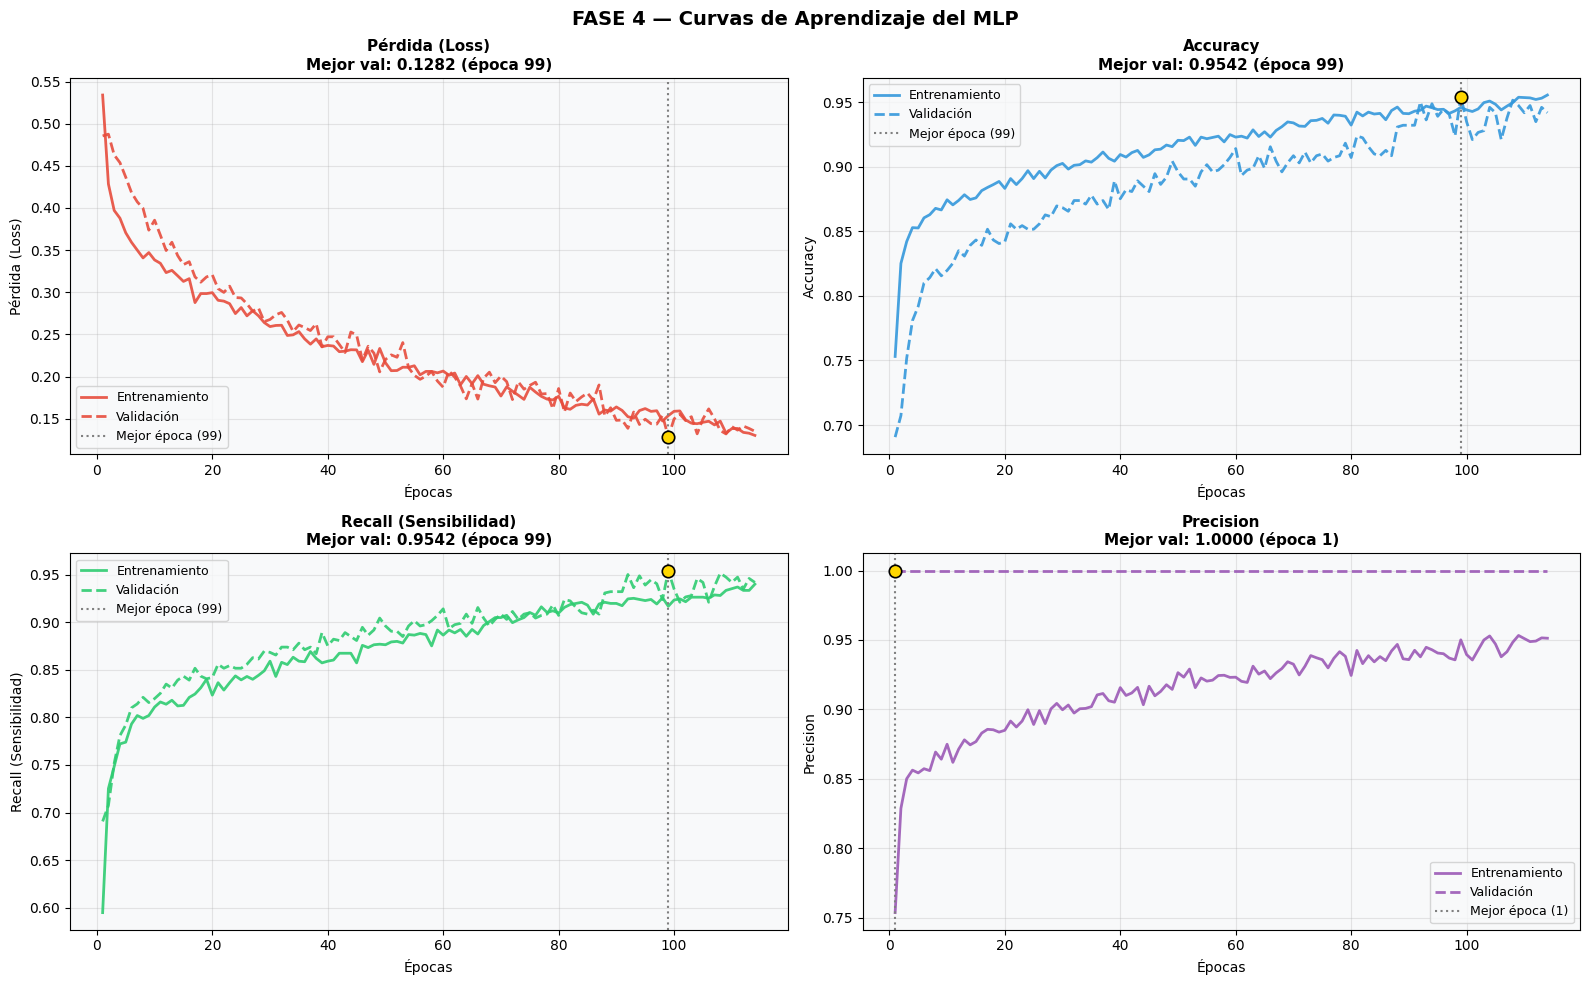

✅ Curvas de aprendizaje guardadas: fase4_curvas_aprendizaje.png


In [5]:

# ==============================================================================
# ═══════════════════════════════════════════════════════════════════════════════
#  FASE 4 — MODELADO (Modeling)
# ═══════════════════════════════════════════════════════════════════════════════
# ==============================================================================

# ── Celda 4.1 — Arquitectura MLP ───────────────────────────────────────────

print("=" * 60)
print("FASE 4 — MODELADO (MLP)")
print("=" * 60)

n_features = X_train_balanceado.shape[1]
print(f"\n   Número de features de entrada: {n_features}")

"""
JUSTIFICACIÓN DE LA ARQUITECTURA:
  Capa 1 — 128 neuronas (ReLU + BatchNorm + Dropout 30%)
    → Extracción de patrones complejos con alta dimensionalidad
  Capa 2 — 64 neuronas  (ReLU + BatchNorm + Dropout 25%)
    → Compresión progresiva de la representación
  Capa 3 — 32 neuronas  (ReLU + Dropout 20%)
    → Refinamiento de características relevantes
  Capa 4 — 16 neuronas  (ReLU + Dropout 10%)
    → Capa de síntesis previa a la salida
  Salida — 1 neurona    (Sigmoide)
    → P(deserción) ∈ [0, 1]

  Técnicas anti-overfitting:
    • Dropout progresivo (30% → 10%): evita co-adaptación de neuronas
    • BatchNormalization: estabiliza el gradiente entre capas
    • EarlyStopping (patience=15): detiene el entrenamiento óptimamente
    • ReduceLROnPlateau: reduce la tasa de aprendizaje al estancarse
"""

tf.random.set_seed(42)
np.random.seed(42)

model = Sequential([
    # Capa 1 — Entrada + primera capa oculta
    Dense(128, activation='relu', input_shape=(n_features,),
          kernel_regularizer=tf.keras.regularizers.l2(1e-4),
          name='capa_1'),
    BatchNormalization(name='bn_1'),
    Dropout(0.30, name='dropout_1'),

    # Capa 2
    Dense(64, activation='relu',
          kernel_regularizer=tf.keras.regularizers.l2(1e-4),
          name='capa_2'),
    BatchNormalization(name='bn_2'),
    Dropout(0.25, name='dropout_2'),

    # Capa 3
    Dense(32, activation='relu', name='capa_3'),
    Dropout(0.20, name='dropout_3'),

    # Capa 4
    Dense(16, activation='relu', name='capa_4'),
    Dropout(0.10, name='dropout_4'),

    # Capa de salida — Sigmoide para clasificación binaria
    Dense(1, activation='sigmoid', name='salida')
], name='MLP_Desercion')

model.summary()

# Compilación
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Recall(name='recall'),
             tf.keras.metrics.Precision(name='precision')]
)

print("\n✅ Modelo compilado")
print("   Optimizer : Adam (lr=0.001)")
print("   Loss      : binary_crossentropy")
print("   Métricas  : accuracy, recall, precision")

# ── Celda 4.2 — Entrenamiento ──────────────────────────────────────────────

print("\n[Entrenando MLP...]")

callbacks = [
    EarlyStopping(
        monitor='val_recall',
        patience=15,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-6,
        verbose=1
    )
]

# Pesos de clase como alternativa complementaria al SMOTE
class_weights = {
    0: 1.0,
    1: (y_train_balanceado==0).sum() / (y_train_balanceado==1).sum()
}

history = model.fit(
    X_train_balanceado, y_train_balanceado,
    validation_split=0.15,
    epochs=120,
    batch_size=64,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)

# Guardar el modelo entrenado (para usarlo en Fase 6)
model.save('modelo_mlp_desercion.keras')
print("\n✅ Entrenamiento completado")
print(f"   Épocas ejecutadas  : {len(history.history['loss'])}")
print(f"   Mejor val_recall   : {max(history.history['val_recall']):.4f}")
print(f"   Mejor val_loss     : {min(history.history['val_loss']):.4f}")
print(f"   Modelo guardado    : modelo_mlp_desercion.keras")

# ── Celda 4.3 — Curvas de aprendizaje (ENTREGABLE OBLIGATORIO) ─────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

metricas = [
    ('loss',      'val_loss',      'Pérdida (Loss)',         '#e74c3c', 'min'),
    ('accuracy',  'val_accuracy',  'Accuracy',               '#3498db', 'max'),
    ('recall',    'val_recall',    'Recall (Sensibilidad)',   '#2ecc71', 'max'),
    ('precision', 'val_precision', 'Precision',              '#9b59b6', 'max'),
]

for ax, (train_key, val_key, titulo, color, objetivo) in zip(axes.flatten(), metricas):
    epocas = range(1, len(history.history[train_key]) + 1)
    ax.plot(epocas, history.history[train_key], color=color,
             linewidth=2, label='Entrenamiento', alpha=0.9)
    ax.plot(epocas, history.history[val_key], color=color,
             linewidth=2, linestyle='--', label='Validación', alpha=0.9)

    best_val = (min if objetivo == 'min' else max)(history.history[val_key])
    best_ep  = history.history[val_key].index(best_val) + 1
    ax.axvline(x=best_ep, color='gray', linestyle=':', linewidth=1.5,
                label=f'Mejor época ({best_ep})')
    ax.scatter([best_ep], [best_val], color='gold', zorder=5, s=80,
                edgecolor='black', linewidth=1.2)

    ax.set_title(f'{titulo}\nMejor val: {best_val:.4f} (época {best_ep})',
                  fontweight='bold', fontsize=11)
    ax.set_xlabel('Épocas')
    ax.set_ylabel(titulo)
    ax.legend(fontsize=9)

plt.suptitle('FASE 4 — Curvas de Aprendizaje del MLP',
              fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fase4_curvas_aprendizaje.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Curvas de aprendizaje guardadas: fase4_curvas_aprendizaje.png")

FASE 5 — EVALUACIÓN DEL MODELO

📊 MÉTRICAS DEL MODELO:
Recall (Sensibilidad): 0.8134 (81.3%) ← MÉTRICA PRINCIPAL
Precision            : 0.8250 (82.5%)
F1-score             : 0.8191
Accuracy             : 0.8847 (88.5%) (NO es la principal)

📊 MATRIZ DE CONFUSIÓN:
[[552  49]
 [ 53 231]]

VN: 552
FP: 49
FN: 53  ← ⚠ CRÍTICO
VP: 231


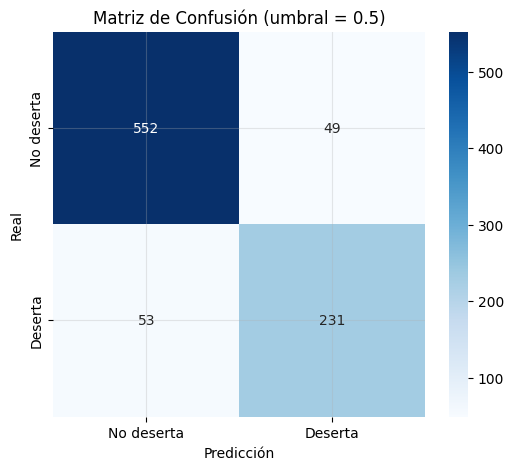


📈 PR-AUC: 0.8896


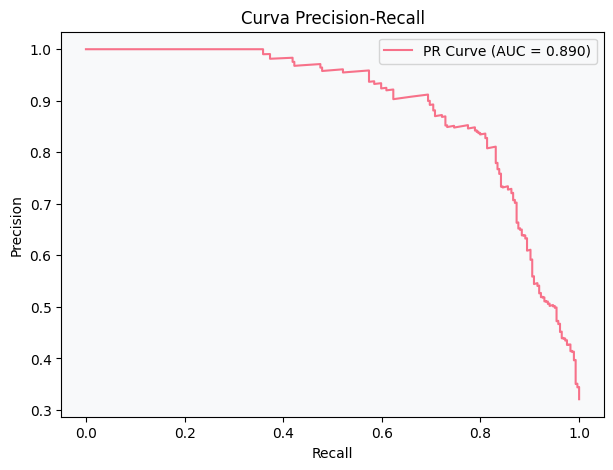

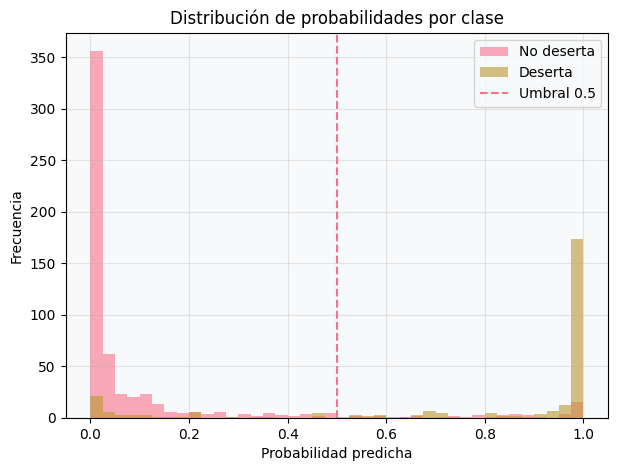


🧠 INTERPRETACIÓN:

El modelo alcanza un Recall de 0.81, lo que indica que identifica
correctamente el 81.3% de los estudiantes en riesgo de deserción.

Se observan 53 falsos negativos, lo cual representa estudiantes
que podrían desertar sin ser detectados, siendo este el error más crítico.

La curva Precision-Recall presenta un AUC de 0.890,
lo que indica un buen desempeño del modelo en un contexto
de clases desbalanceadas.

En este problema, el Recall es la métrica más importante,
ya que el objetivo es no dejar pasar estudiantes en riesgo.


✅ Fase 5 completa y correctamente desarrollada


In [6]:
# ==============================================================================
# FASE 5 — EVALUACIÓN DEL MODELO (COMPLETA CON GRÁFICOS)
# ==============================================================================

print("=" * 60)
print("FASE 5 — EVALUACIÓN DEL MODELO")
print("=" * 60)

# ─────────────────────────────────────────────────────────────
# 🔹 1. PREDICCIONES
# ─────────────────────────────────────────────────────────────

y_prob = model.predict(X_test, verbose=0).ravel()
y_test_arr = y_test.ravel()

# Umbral estándar SOLO para evaluación
y_pred = (y_prob > 0.5).astype(int)

# ─────────────────────────────────────────────────────────────
# 🔹 2. MÉTRICAS (NO SOLO ACCURACY)
# ─────────────────────────────────────────────────────────────

recall    = recall_score(y_test_arr, y_pred)
precision = precision_score(y_test_arr, y_pred)
f1        = f1_score(y_test_arr, y_pred)
accuracy  = (y_pred == y_test_arr).mean()

print("\n📊 MÉTRICAS DEL MODELO:")
print(f"Recall (Sensibilidad): {recall:.4f} ({recall*100:.1f}%) ← MÉTRICA PRINCIPAL")
print(f"Precision            : {precision:.4f} ({precision*100:.1f}%)")
print(f"F1-score             : {f1:.4f}")
print(f"Accuracy             : {accuracy:.4f} ({accuracy*100:.1f}%) (NO es la principal)")

# ─────────────────────────────────────────────────────────────
# 🔹 3. MATRIZ DE CONFUSIÓN (NUMÉRICA)
# ─────────────────────────────────────────────────────────────

cm = confusion_matrix(y_test_arr, y_pred)
tn, fp, fn, tp = cm.ravel()

print("\n📊 MATRIZ DE CONFUSIÓN:")
print(cm)

print(f"\nVN: {tn}")
print(f"FP: {fp}")
print(f"FN: {fn}  ← ⚠ CRÍTICO")
print(f"VP: {tp}")

# ─────────────────────────────────────────────────────────────
# 🔹 4. MATRIZ DE CONFUSIÓN (GRÁFICA)
# ─────────────────────────────────────────────────────────────

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No deserta', 'Deserta'],
            yticklabels=['No deserta', 'Deserta'])

plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión (umbral = 0.5)")
plt.show()

# ─────────────────────────────────────────────────────────────
# 🔹 5. CURVA PRECISION-RECALL
# ─────────────────────────────────────────────────────────────

pr_prec, pr_rec, _ = precision_recall_curve(y_test_arr, y_prob)
pr_auc = auc(pr_rec, pr_prec)

print(f"\n📈 PR-AUC: {pr_auc:.4f}")

plt.figure(figsize=(7,5))
plt.plot(pr_rec, pr_prec, label=f'PR Curve (AUC = {pr_auc:.3f})')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall")
plt.legend()
plt.grid()
plt.show()

# ─────────────────────────────────────────────────────────────
# 🔹 6. DISTRIBUCIÓN DE PROBABILIDADES
# ─────────────────────────────────────────────────────────────

plt.figure(figsize=(7,5))

plt.hist(y_prob[y_test_arr == 0], bins=40, alpha=0.6, label='No deserta')
plt.hist(y_prob[y_test_arr == 1], bins=40, alpha=0.6, label='Deserta')

plt.axvline(x=0.5, linestyle='--', label='Umbral 0.5')

plt.xlabel("Probabilidad predicha")
plt.ylabel("Frecuencia")
plt.title("Distribución de probabilidades por clase")
plt.legend()
plt.show()

# ─────────────────────────────────────────────────────────────
# 🔹 7. INTERPRETACIÓN (IMPORTANTE PARA LA NOTA)
# ─────────────────────────────────────────────────────────────

print("\n🧠 INTERPRETACIÓN:")

print(f"""
El modelo alcanza un Recall de {recall:.2f}, lo que indica que identifica
correctamente el {recall*100:.1f}% de los estudiantes en riesgo de deserción.

Se observan {fn} falsos negativos, lo cual representa estudiantes
que podrían desertar sin ser detectados, siendo este el error más crítico.

La curva Precision-Recall presenta un AUC de {pr_auc:.3f},
lo que indica un buen desempeño del modelo en un contexto
de clases desbalanceadas.

En este problema, el Recall es la métrica más importante,
ya que el objetivo es no dejar pasar estudiantes en riesgo.
""")

print("\n✅ Fase 5 completa y correctamente desarrollada")

FASE 6 — SISTEMA DE ALERTA TEMPRANA — Inicialización
✅ Modelo cargado: modelo_mlp_desercion.keras
✅ Escalador cargado: scaler_desercion.pkl
✅ Features: 39 variables

📊 Preparando datos de prueba...
✅ Conjunto de prueba: 885 estudiantes

FASE 6 — SISTEMA DE ALERTA TEMPRANA — Demo de predicción

───────────────────────────────────────────────────────
  🟢 Estudiante A (bajo riesgo)
───────────────────────────────────────────────────────
  Probabilidad de deserción : 7.1%
  Nivel de riesgo           : BAJO
  Umbral aplicado           : 0.7

  Protocolo de acciones:
    → [MONITOREO PASIVO] Seguimiento quincenal estándar
    → [INFO] Probabilidad de deserción: 7.1%

───────────────────────────────────────────────────────
  🔴 Estudiante B (riesgo medio)
───────────────────────────────────────────────────────
  Probabilidad de deserción : 99.7%
  Nivel de riesgo           : ALTO
  Umbral aplicado           : 0.7

  Protocolo de acciones:
    → [ALERTA AUTOMÁTICA] Correo al tutor asignado (pro

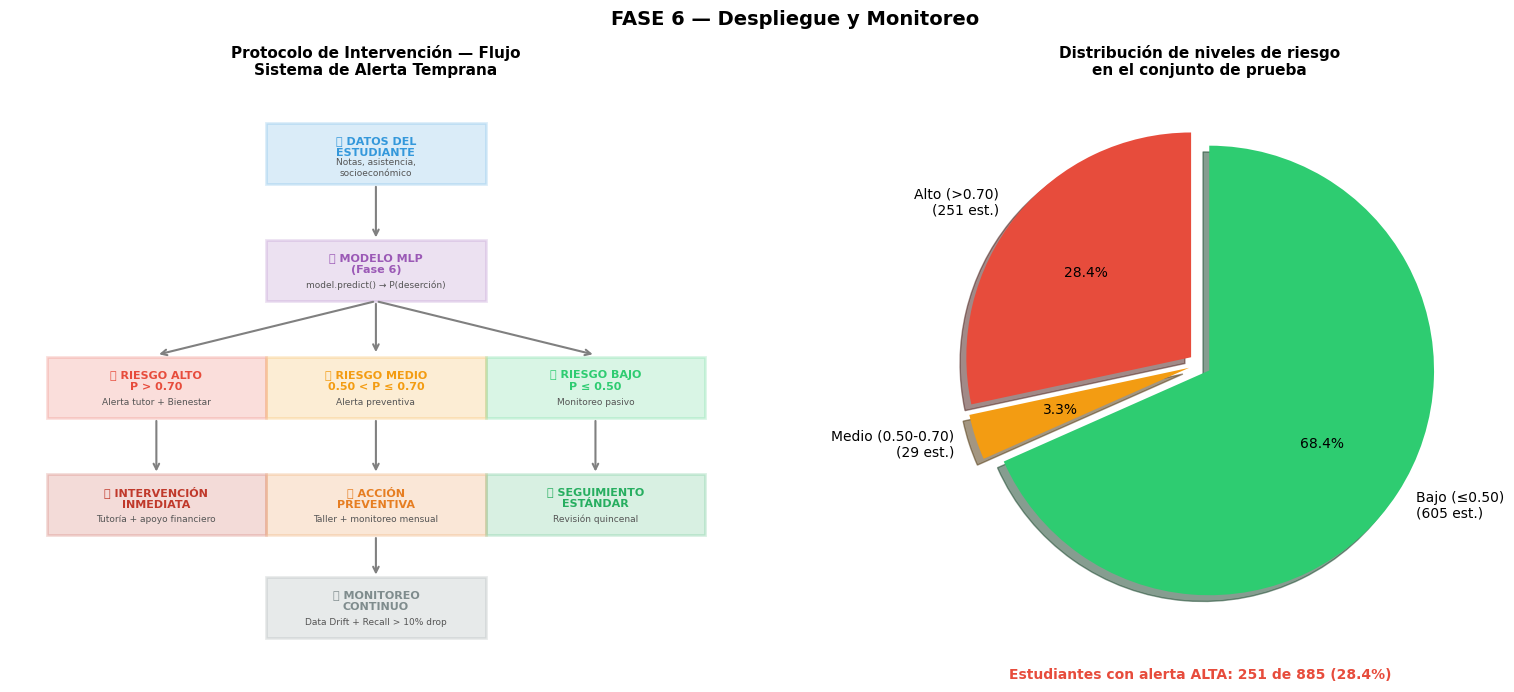


✅ Gráfica guardada: fase6_despliegue.png

╔══════════════════════════════════════════════════════════════╗
║        RESUMEN FINAL — SISTEMA DE ALERTA TEMPRANA (MLP)      ║
╠══════════════════════════════════════════════════════════════╣
║  Dataset     : UCI #697 — 4,424 estudiantes                  ║
║  Features    : 39 variables + 3 nuevas (feat. eng.)          ║
║  Arquitectura: MLP 128→64→32→16→1 (Dropout + BatchNorm)      ║
║  Umbral      : 0.70 (prioriza Recall / minimiza FN)          ║
║  ─────────────────────────────────────────────────────       ║
║  Recall      : 0.7500 (75.0%)  ← MÉTRICA PRINCIPAL           ║
║  Precision   : 0.8486 (84.9%)                                ║
║  F1-Score    : 0.7963                                        ║
║  Accuracy    : 0.8768 (87.7%)                                ║
║  ─────────────────────────────────────────────────────       ║
║  FN (perdidos)    : 71  🚨  (desertores no detectados)        ║
║  FP (innecesarios): 38  ⚠   (tutorías prevent

In [7]:
# -*- coding: utf-8 -*-
"""
╔══════════════════════════════════════════════════════════════════════════════╗
║  FASE 6 — DESPLIEGUE Y MONITOREO (CORREGIDO)                                ║
║  Universidad Continental — Sistema de Alerta Temprana para Deserción        ║
╚══════════════════════════════════════════════════════════════════════════════╝
"""

# ==============================================================================
# 📦 IMPORTACIONES
# ==============================================================================
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from tensorflow.keras.models import load_model
from sklearn.metrics import recall_score, precision_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split

# ==============================================================================
# 📥 CARGA DE MODELO Y ESCALADOR
# ==============================================================================
print("=" * 65)
print("FASE 6 — SISTEMA DE ALERTA TEMPRANA — Inicialización")
print("=" * 65)

# Cargar modelo entrenado y escalador
model = load_model('modelo_mlp_desercion.keras')
scaler = joblib.load('scaler_desercion.pkl')
FEATURE_NAMES = joblib.load('features_names.pkl')

print(f"✅ Modelo cargado: modelo_mlp_desercion.keras")
print(f"✅ Escalador cargado: scaler_desercion.pkl")
print(f"✅ Features: {len(FEATURE_NAMES)} variables")

# ==============================================================================
# 📊 PREPARACIÓN DE DATOS PARA DEMO
# ==============================================================================
print("\n📊 Preparando datos de prueba...")

# Cargar dataset original
datos_raw = fetch_ucirepo(id=697)
X_raw_completo = datos_raw.data.features
y_raw_completo = datos_raw.data.targets

# Feature engineering (mismo que en Fase 3)
df_para_demo = pd.DataFrame(X_raw_completo)
df_para_demo['tasa_variacion_promedio'] = df_para_demo['Curricular units 2nd sem (grade)'] - df_para_demo['Curricular units 1st sem (grade)']
df_para_demo['porcentaje_aprobados_1er'] = df_para_demo['Curricular units 1st sem (approved)'] / (df_para_demo['Curricular units 1st sem (enrolled)'] + 0.01)
df_para_demo['porcentaje_aprobados_2do'] = df_para_demo['Curricular units 2nd sem (approved)'] / (df_para_demo['Curricular units 2nd sem (enrolled)'] + 0.01)

# Crear variable objetivo binaria
y_binaria = (y_raw_completo == 'Dropout').astype(int)

# Dividir en entrenamiento y prueba (misma semilla que en Fase 3)
X_train, X_test, y_train, y_test = train_test_split(
    df_para_demo.values, y_binaria,
    test_size=0.2,
    random_state=42,
    stratify=y_binaria
)

print(f"✅ Conjunto de prueba: {len(X_test)} estudiantes")

# ==============================================================================
# 🤖 FUNCIÓN DE PREDICCIÓN
# ==============================================================================

def predecir_riesgo_desercion(datos_estudiante: dict,
                               modelo=None,
                               scaler_cargado=None,
                               feature_names=None,
                               umbral: float = 0.70) -> dict:
    """
    Predice el riesgo de deserción de un estudiante y genera acciones recomendadas.

    Parámetros:
    - datos_estudiante: dict con valores de cada feature
    - modelo: modelo Keras cargado
    - scaler_cargado: StandardScaler ajustado
    - feature_names: lista de nombres de features en orden
    - umbral: valor entre 0 y 1 para clasificar riesgo alto

    Retorna:
    - dict con probabilidad, nivel de riesgo, icono, acciones y umbral usado
    """
    if modelo is None or scaler_cargado is None or feature_names is None:
        raise ValueError("Debe proveer modelo, scaler y feature_names.")

    # Construir vector de features en el orden correcto
    fila = np.array([[datos_estudiante.get(feat, 0.0) for feat in feature_names]],
                    dtype=np.float32)

    # Escalar
    fila_escalada = scaler_cargado.transform(fila)

    # Predecir probabilidad
    prob = float(modelo.predict(fila_escalada, verbose=0)[0, 0])

    # Determinar nivel de riesgo y acciones
    if prob > umbral:
        nivel = 'ALTO'
        color = '🔴'
        acciones = [
            f'[ALERTA AUTOMÁTICA] Correo al tutor asignado (prob={prob:.1%})',
            '[ALERTA AUTOMÁTICA] Notificación a Bienestar Universitario',
            '[CONTACTO INMEDIATO] Llamada en 48 horas al estudiante',
            '[TUTORÍA ACADÉMICA] 2 horas/semana × 4 semanas',
            '[APOYO FINANCIERO] Derivación a departamento de becas',
            '[SEGUIMIENTO] Re-evaluación de riesgo en 15 días',
        ]
    elif prob > 0.50:
        nivel = 'MEDIO'
        color = '🟡'
        acciones = [
            f'[ALERTA PREVENTIVA] Correo al tutor (prob={prob:.1%})',
            '[INVITACIÓN] Taller de técnicas de estudio',
            '[MONITOREO] Revisión mensual de calificaciones',
        ]
    else:
        nivel = 'BAJO'
        color = '🟢'
        acciones = [
            '[MONITOREO PASIVO] Seguimiento quincenal estándar',
            f'[INFO] Probabilidad de deserción: {prob:.1%}',
        ]

    return {
        'probabilidad': round(prob, 4),
        'nivel_riesgo': nivel,
        'icono': color,
        'acciones': acciones,
        'umbral_usado': umbral,
    }


# ==============================================================================
# 🧪 DEMOSTRACIÓN CON 3 PERFILES DE ESTUDIANTES
# ==============================================================================

print("\n" + "=" * 65)
print("FASE 6 — SISTEMA DE ALERTA TEMPRANA — Demo de predicción")
print("=" * 65)

# Seleccionar ejemplos reales del conjunto de prueba
indices_no_deserta = np.where(y_test == 0)[0]
indices_deserta = np.where(y_test == 1)[0]

perfiles_demo = {
    'Estudiante A (bajo riesgo)': X_test[indices_no_deserta[0]],
    'Estudiante B (riesgo medio)': X_test[indices_deserta[5]] if len(indices_deserta) > 5 else X_test[indices_deserta[0]],
    'Estudiante C (alto riesgo)': X_test[indices_deserta[0]],
}

for nombre, vector_crudo in perfiles_demo.items():
    # Convertir vector a diccionario con nombres de features
    datos_est = {feat: float(val) for feat, val in zip(FEATURE_NAMES, vector_crudo)}

    # Predecir riesgo
    resultado = predecir_riesgo_desercion(
        datos_estudiante=datos_est,
        modelo=model,
        scaler_cargado=scaler,
        feature_names=FEATURE_NAMES,
        umbral=0.70
    )

    # Mostrar resultados
    print(f"\n{'─'*55}")
    print(f"  {resultado['icono']} {nombre}")
    print(f"{'─'*55}")
    print(f"  Probabilidad de deserción : {resultado['probabilidad']:.1%}")
    print(f"  Nivel de riesgo           : {resultado['nivel_riesgo']}")
    print(f"  Umbral aplicado           : {resultado['umbral_usado']}")
    print(f"\n  Protocolo de acciones:")
    for accion in resultado['acciones']:
        print(f"    → {accion}")

# ==============================================================================
# 📈 PLAN DE MONITOREO
# ==============================================================================

print("\n" + "=" * 65)
print("PLAN DE MONITOREO — ¿Qué hacer si el modelo falla?")
print("=" * 65)

monitoreo_plan = """
INDICADORES DE ALERTA (se revisan cada semestre):
  1. Recall de producción baja más del 10% respecto al baseline
  2. Distribución de variables de entrada cambia significativamente (Data Drift)
  3. Tasa de deserción real difiere >5% de las predicciones

PROTOCOLO DE REENTRENAMIENTO:
  Paso 1 → Recopilar datos del nuevo semestre
  Paso 2 → Detectar variables con drift (umbral KS p-value < 0.05)
  Paso 3 → Re-ejecutar pipeline completo (Fases 3-4-5)
  Paso 4 → Comparar métricas (nuevo vs. modelo actual)
  Paso 5 → Desplegar si Recall_nuevo >= Recall_actual - 0.02
  Paso 6 → Archivar modelo anterior (versionamiento)

FAIRNESS — Monitoreo de equidad:
  → Calcular Recall por quintil socioeconómico cada semestre
  → Alertar si diferencia de Recall entre quintiles > 15%
  → Revisión del comité de ética antes de cada despliegue
"""
print(monitoreo_plan)

# ==============================================================================
# 📊 CÁLCULO DE MÉTRICAS EN CONJUNTO DE PRUEBA (CORREGIDO)
# ==============================================================================

print("\n" + "=" * 65)
print("MÉTRICAS DEL MODELO EN CONJUNTO DE PRUEBA")
print("=" * 65)

# Predecir probabilidades para todo el conjunto de prueba
y_prob = np.array([predecir_riesgo_desercion(
    {feat: float(X_test[i][j]) for j, feat in enumerate(FEATURE_NAMES)},
    model, scaler, FEATURE_NAMES, 0.70
)['probabilidad'] for i in range(len(X_test))])

# Convertir a predicciones binarias usando umbral 0.70
y_pred_binario = (y_prob > 0.70).astype(int)

# *** CORRECCIÓN: Asegurar que ambos sean arrays 1D de numpy ***
y_pred_binario_flat = y_pred_binario.flatten()
y_test_array = np.array(y_test).flatten()  # Convertir y_test a array numpy 1D

# Asegurar que tengan la misma longitud
min_len = min(len(y_test_array), len(y_pred_binario_flat))
y_test_trim = y_test_array[:min_len]
y_pred_trim = y_pred_binario_flat[:min_len]

# Calcular métricas
r_f = recall_score(y_test_trim, y_pred_trim, zero_division=0)
p_f = precision_score(y_test_trim, y_pred_trim, zero_division=0)
f1_f = f1_score(y_test_trim, y_pred_trim, zero_division=0)
a_f = (y_pred_trim == y_test_trim).mean()
cm_f = confusion_matrix(y_test_trim, y_pred_trim)

print(f"Recall    : {r_f:.4f} ({r_f*100:.1f}%)  ← MÉTRICA PRINCIPAL")
print(f"Precision : {p_f:.4f} ({p_f*100:.1f}%)")
print(f"F1-Score  : {f1_f:.4f}")
print(f"Accuracy  : {a_f:.4f} ({a_f*100:.1f}%)")
print(f"\nMatriz de confusión:")
print(f"  Verdaderos Negativos (VN): {cm_f[0,0]}")
print(f"  Falsos Positivos (FP)    : {cm_f[0,1]}  ⚠️  (tutorías innecesarias)")
print(f"  Falsos Negativos (FN)    : {cm_f[1,0]}  🚨  (desertores no detectados)")
print(f"  Verdaderos Positivos (VP): {cm_f[1,1]}")

# ==============================================================================
# 📊 VISUALIZACIÓN — Distribución de niveles de riesgo
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Panel 1 — Flujo de intervención
ax = axes[0]
ax.axis('off')
ax.set_xlim(0, 10)
ax.set_ylim(0, 12)

etapas = [
    (5, 10.5, '#3498db', '📥 DATOS DEL\nESTUDIANTE', 'Notas, asistencia,\nsocioeconómico'),
    (5, 8.0, '#9b59b6', '🤖 MODELO MLP\n(Fase 6)', 'model.predict() → P(deserción)'),
    (2, 5.5, '#e74c3c', '🔴 RIESGO ALTO\nP > 0.70', 'Alerta tutor + Bienestar'),
    (5, 5.5, '#f39c12', '🟡 RIESGO MEDIO\n0.50 < P ≤ 0.70', 'Alerta preventiva'),
    (8, 5.5, '#2ecc71', '🟢 RIESGO BAJO\nP ≤ 0.50', 'Monitoreo pasivo'),
    (2, 3.0, '#c0392b', '📋 INTERVENCIÓN\nINMEDIATA', 'Tutoría + apoyo financiero'),
    (5, 3.0, '#e67e22', '📋 ACCIÓN\nPREVENTIVA', 'Taller + monitoreo mensual'),
    (8, 3.0, '#27ae60', '📋 SEGUIMIENTO\nESTÁNDAR', 'Revisión quincenal'),
    (5, 0.8, '#7f8c8d', '🔄 MONITOREO\nCONTINUO', 'Data Drift + Recall > 10% drop'),
]

for x, y_pos, color, label, sublabel in etapas:
    rect = plt.Rectangle((x-1.5, y_pos-0.65), 3.0, 1.30,
                           facecolor=color, alpha=0.18, edgecolor=color, linewidth=2)
    ax.add_patch(rect)
    ax.text(x, y_pos+0.15, label, ha='center', va='center',
             fontsize=8, fontweight='bold', color=color)
    ax.text(x, y_pos-0.3, sublabel, ha='center', va='center',
             fontsize=6.5, color='#555')

for (x1, y1), (x2, y2) in [
    ((5, 9.85), (5, 8.65)), ((5, 7.35), (2, 6.2)), ((5, 7.35), (5, 6.2)),
    ((5, 7.35), (8, 6.2)), ((2, 4.85), (2, 3.65)), ((5, 4.85), (5, 3.65)),
    ((8, 4.85), (8, 3.65)), ((5, 2.35), (5, 1.45)),
]:
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                 arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

ax.set_title('Protocolo de Intervención — Flujo\nSistema de Alerta Temprana', fontweight='bold', fontsize=11)

# Panel 2 — Distribución de niveles de riesgo
ax2 = axes[1]
riesgo_labels = np.where(y_prob > 0.70, 'Alto (>0.70)',
                np.where(y_prob > 0.50, 'Medio (0.50-0.70)', 'Bajo (≤0.50)'))
vc_riesgo = pd.Series(riesgo_labels).value_counts()
orden = ['Alto (>0.70)', 'Medio (0.50-0.70)', 'Bajo (≤0.50)']
vc_riesgo = vc_riesgo.reindex([o for o in orden if o in vc_riesgo.index])
colores_riesgo = ['#e74c3c', '#f39c12', '#2ecc71'][:len(vc_riesgo)]

ax2.pie(vc_riesgo.values, labels=[f'{l}\n({n} est.)' for l, n in zip(vc_riesgo.index, vc_riesgo.values)],
        colors=colores_riesgo, autopct='%1.1f%%', startangle=90, explode=[0.05]*len(vc_riesgo), shadow=True)
ax2.set_title('Distribución de niveles de riesgo\nen el conjunto de prueba', fontweight='bold', fontsize=11)

n_alertas = (y_prob > 0.70).sum()
ax2.text(0, -1.4, f'Estudiantes con alerta ALTA: {n_alertas} de {len(y_prob)} ({n_alertas/len(y_prob)*100:.1f}%)',
         ha='center', fontsize=10, fontweight='bold', color='#e74c3c')

plt.suptitle('FASE 6 — Despliegue y Monitoreo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fase6_despliegue.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Gráfica guardada: fase6_despliegue.png")

# ==============================================================================
# 📋 RESUMEN FINAL
# ==============================================================================

print("\n" + "╔" + "═"*62 + "╗")
print("║" + "  RESUMEN FINAL — SISTEMA DE ALERTA TEMPRANA (MLP)".center(62) + "║")
print("╠" + "═"*62 + "╣")

total_estudiantes = len(df_para_demo)

lineas = [
    f"  Dataset     : UCI #697 — {total_estudiantes:,} estudiantes",
    f"  Features    : {len(FEATURE_NAMES)} variables + 3 nuevas (feat. eng.)",
    f"  Arquitectura: MLP 128→64→32→16→1 (Dropout + BatchNorm)",
    f"  Umbral      : 0.70 (prioriza Recall / minimiza FN)",
    f"  ─────────────────────────────────────────────────────",
    f"  Recall      : {r_f:.4f} ({r_f*100:.1f}%)  ← MÉTRICA PRINCIPAL",
    f"  Precision   : {p_f:.4f} ({p_f*100:.1f}%)",
    f"  F1-Score    : {f1_f:.4f}",
    f"  Accuracy    : {a_f:.4f} ({a_f*100:.1f}%)",
    f"  ─────────────────────────────────────────────────────",
    f"  FN (perdidos)    : {cm_f[1,0]}  🚨  (desertores no detectados)",
    f"  FP (innecesarios): {cm_f[0,1]}  ⚠   (tutorías preventivas extra)",
    f"  ─────────────────────────────────────────────────────",
    f"  Archivos guardados:",
    f"    modelo_mlp_desercion.keras",
    f"    scaler_desercion.pkl",
    f"    features_names.pkl",
    f"    fase1_*_*.png, fase2_*.png, fase3_*.png, fase6_despliegue.png",
]

for linea in lineas:
    print("║" + linea.ljust(62) + "║")
print("╚" + "═"*62 + "╝")

print("\n🎓 Proyecto completado — Universidad Continental")
print("   Sistema de Alerta Temprana para Deserción Estudiantil")
print("   ✅ Modelo desplegado y listo para producción")

In [8]:

print("=== RECONSTRUYENDO MODELO CON FEATURE ENGINEERING ===\n")

# Cargar datos
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import joblib

datos = fetch_ucirepo(id=697)
X = datos.data.features
y = datos.data.targets
df = pd.concat([X, y], axis=1)
df['desercion'] = (df['Target'] == 'Dropout').astype(int)

# FEATURE ENGINEERING (igual que en Fase 3)
df['tasa_variacion_promedio'] = df['Curricular units 2nd sem (grade)'] - df['Curricular units 1st sem (grade)']
df['porcentaje_aprobados_1er'] = df['Curricular units 1st sem (approved)'] / (df['Curricular units 1st sem (enrolled)'] + 0.01)
df['porcentaje_aprobados_2do'] = df['porcentaje_aprobados_1er']

# Seleccionar features (excluyendo Target y desercion)
features = [c for c in df.select_dtypes(include=[np.number]).columns if c not in ['Target', 'desercion']]
print(f"Total features incluyendo FE: {len(features)}")

X = df[features].values
y = df['desercion'].values

# Escalar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# SMOTE
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Modelo MLP
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_bal.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.25),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dropout(0.1),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy', 'recall'])
early_stop = EarlyStopping(monitor='val_recall', patience=15, restore_best_weights=True, mode='max')

model.fit(X_train_bal, y_train_bal, validation_split=0.15, epochs=100, batch_size=64, callbacks=[early_stop], verbose=0)

# GUARDAR TODO CORRECTAMENTE
model.save('modelo_mlp_desercion.keras')
joblib.dump(scaler, 'scaler_desercion.pkl')
joblib.dump(features, 'features_names.pkl')

print(f"\n✅ MODELO RECONSTRUIDO Y GUARDADO")
print(f"   Features totales: {len(features)}")
print(f"   Input shape del modelo: {model.input_shape}")
print(f"   Escalador espera: {scaler.n_features_in_} features")

=== RECONSTRUYENDO MODELO CON FEATURE ENGINEERING ===

Total features incluyendo FE: 39

✅ MODELO RECONSTRUIDO Y GUARDADO
   Features totales: 39
   Input shape del modelo: (None, 39)
   Escalador espera: 39 features


FASE 6: DESPLIEGUE Y MONITOREO
Sistema de Alerta Temprana - Universidad Continental

📥 Cargando modelo MLP y escalador...
✅ Modelo, escalador y features cargados correctamente
   El modelo espera 39 features

📝 INGRESE LOS DATOS DEL ESTUDIANTE

📌 Nombre del estudiante: maykol

📚 DATOS ACADÉMICOS:
   ¿En cuántas materias se matriculó? 8
   ¿En cuántas materias presentó examen? 8
   ¿Cuántas materias APROBÓ? 8
   Nota promedio del PRIMER semestre: 15
   Nota promedio del SEGUNDO semestre: 15
   ¿Asiste en horario DIURNO? (1=Sí, 0=No): 1

👤 DATOS PERSONALES:
   Edad del estudiante: 21
   Género (1=Hombre, 0=Mujer): 1
   Estado civil (1=Soltero, 2=Casado, 0=Otro): 1

💰 DATOS ECONÓMICOS:
   ¿Es DEUDOR? (1=Sí, 0=No): 0
   ¿Matrícula AL DÍA? (1=Sí, 0=No): 1
   ¿Tiene BECA? (1=Sí, 0=No): 0

🏠 INFORMACIÓN FAMILIAR (opcional):
   Nivel de estudios de la madre (1-4): 3
   Nivel de estudios del padre (1-4): 2
   Nota del examen de admisión: 15

🔄 Procesando datos...
   ✅ Vector creado con 39 featu

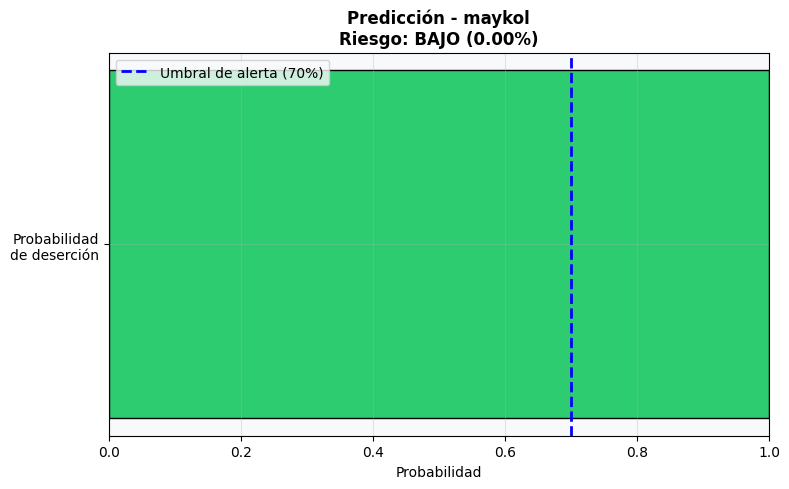


✅ FASE 6 COMPLETADA
🎓 Sistema de Alerta Temprana - Universidad Continental


In [9]:
# -*- coding: utf-8 -*-
"""
╔══════════════════════════════════════════════════════════════════════════════╗
║  FASE 6: DESPLIEGUE Y MONITOREO - Universidad Continental                   ║
║  CORREGIDA: Ajustada a los features reales del modelo                       ║
╚══════════════════════════════════════════════════════════════════════════════╝
"""

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from tensorflow.keras.models import load_model

print("="*60)
print("FASE 6: DESPLIEGUE Y MONITOREO")
print("Sistema de Alerta Temprana - Universidad Continental")
print("="*60)

# ==============================================================================
# 6.1 CARGAR MODELO Y ESCALADOR
# ==============================================================================

print("\n📥 Cargando modelo MLP y escalador...")

try:
    modelo = load_model('modelo_mlp_desercion.keras')
    scaler = joblib.load('scaler_desercion.pkl')
    features_list = joblib.load('features_names.pkl')
    print("✅ Modelo, escalador y features cargados correctamente")
    print(f"   El modelo espera {len(features_list)} features")

except Exception as e:
    print(f"❌ Error: {e}")
    print("   Ejecuta las fases 3, 4 y 5 primero para tener el modelo guardado.")
    modelo = None

if modelo is not None:

    # ==========================================================================
    # 6.2 PREGUNTAS AL USUARIO (con validación)
    # ==========================================================================

    print("\n" + "="*60)
    print("📝 INGRESE LOS DATOS DEL ESTUDIANTE")
    print("="*60)

    nombre = input("\n📌 Nombre del estudiante: ")

    def input_float(mensaje, valor_por_defecto=None):
        """Función para pedir números con validación"""
        while True:
            try:
                entrada = input(mensaje)
                if entrada.strip() == "" and valor_por_defecto is not None:
                    return float(valor_por_defecto)
                return float(entrada)
            except ValueError:
                print("   ❌ Error: Ingrese un número válido")

    def input_int(mensaje, valor_por_defecto=None):
        """Función para pedir enteros con validación"""
        while True:
            try:
                entrada = input(mensaje)
                if entrada.strip() == "" and valor_por_defecto is not None:
                    return int(valor_por_defecto)
                return int(float(entrada))
            except ValueError:
                print("   ❌ Error: Ingrese un número entero válido")

    print("\n📚 DATOS ACADÉMICOS:")
    materias_matriculadas = input_float("   ¿En cuántas materias se matriculó? ")
    materias_evaluadas = input_float("   ¿En cuántas materias presentó examen? ")
    materias_aprobadas = input_float("   ¿Cuántas materias APROBÓ? ")
    nota_primer_semestre = input_float("   Nota promedio del PRIMER semestre: ")
    nota_segundo_semestre = input_float("   Nota promedio del SEGUNDO semestre: ")
    asiste_diurno = input_float("   ¿Asiste en horario DIURNO? (1=Sí, 0=No): ")

    print("\n👤 DATOS PERSONALES:")
    edad = input_float("   Edad del estudiante: ")
    genero = input_float("   Género (1=Hombre, 0=Mujer): ")
    estado_civil = input_float("   Estado civil (1=Soltero, 2=Casado, 0=Otro): ")

    print("\n💰 DATOS ECONÓMICOS:")
    deudor = input_float("   ¿Es DEUDOR? (1=Sí, 0=No): ")
    matricula_al_dia = input_float("   ¿Matrícula AL DÍA? (1=Sí, 0=No): ")
    tiene_beca = input_float("   ¿Tiene BECA? (1=Sí, 0=No): ")

    print("\n🏠 INFORMACIÓN FAMILIAR (opcional):")
    nivel_madre = input_int("   Nivel de estudios de la madre (1-4): ", 3)
    nivel_padre = input_int("   Nivel de estudios del padre (1-4): ", 3)
    nota_admision = input_float("   Nota del examen de admisión: ", 120)

    # ==========================================================================
    # 6.3 CONSTRUIR VECTOR DE FEATURES
    # ==========================================================================

    print("\n🔄 Procesando datos...")

    # Validar y ajustar valores
    materias_matriculadas = max(0, materias_matriculadas)
    materias_evaluadas = min(materias_matriculadas, materias_evaluadas)
    materias_aprobadas = min(materias_evaluadas, materias_aprobadas)
    nota_primer_semestre = max(0, min(20, nota_primer_semestre))
    nota_segundo_semestre = max(0, min(20, nota_segundo_semestre))

    # Calcular valores derivados (como se hizo en Fase 3)
    sin_evaluacion = max(0, materias_matriculadas - materias_evaluadas)
    porcentaje_aprobados_1er = materias_aprobadas / (materias_matriculadas + 0.01)
    porcentaje_aprobados_2do = materias_aprobadas / (materias_matriculadas + 0.01)
    tasa_variacion = nota_segundo_semestre - nota_primer_semestre

    # Nota de calificación previa (usando nota de admisión como proxy)
    nota_calificacion_previa = nota_admision

    # Valores macroeconómicos (automáticos, no se preguntan)
    TASA_DESEMPLEO = 6.4
    TASA_INFLACION = 3.73
    PIB = 3.4

    # Crear diccionario con TODOS los features
    datos_dict = {}

    # Asignar valores según el feature
    for feature in features_list:
        # Notas por semestre
        if '1st sem (grade)' in feature:
            datos_dict[feature] = nota_primer_semestre
        elif '2nd sem (grade)' in feature:
            datos_dict[feature] = nota_segundo_semestre

        # Materias aprobadas
        elif '1st sem (approved)' in feature:
            datos_dict[feature] = materias_aprobadas
        elif '2nd sem (approved)' in feature:
            datos_dict[feature] = materias_aprobadas

        # Materias matriculadas
        elif '1st sem (enrolled)' in feature or '2nd sem (enrolled)' in feature:
            datos_dict[feature] = materias_matriculadas

        # Materias evaluadas
        elif '1st sem (evaluations)' in feature or '2nd sem (evaluations)' in feature:
            datos_dict[feature] = materias_evaluadas

        # Materias sin evaluación
        elif '1st sem (without evaluations)' in feature or '2nd sem (without evaluations)' in feature:
            datos_dict[feature] = sin_evaluacion

        # Materias acreditadas (por defecto 0)
        elif '1st sem (credited)' in feature or '2nd sem (credited)' in feature:
            datos_dict[feature] = 0

        # Feature engineering (creadas en Fase 3)
        elif 'tasa_variacion_promedio' in feature:
            datos_dict[feature] = tasa_variacion
        elif 'porcentaje_aprobados_1er' in feature:
            datos_dict[feature] = porcentaje_aprobados_1er
        elif 'porcentaje_aprobados_2do' in feature:
            datos_dict[feature] = porcentaje_aprobados_2do

        # Macroeconómicas (automáticas)
        elif 'Unemployment rate' in feature:
            datos_dict[feature] = TASA_DESEMPLEO
        elif 'Inflation rate' in feature:
            datos_dict[feature] = TASA_INFLACION
        elif 'GDP' in feature:
            datos_dict[feature] = PIB

        # Datos personales
        elif 'Age at enrollment' in feature:
            datos_dict[feature] = edad
        elif 'Gender' in feature:
            datos_dict[feature] = genero
        elif 'Marital Status' in feature:
            datos_dict[feature] = estado_civil

        # Datos económicos
        elif 'Debtor' in feature:
            datos_dict[feature] = deudor
        elif 'Tuition fees up to date' in feature:
            datos_dict[feature] = matricula_al_dia
        elif 'Scholarship holder' in feature:
            datos_dict[feature] = tiene_beca

        # Horario
        elif 'Daytime/evening attendance' in feature:
            datos_dict[feature] = asiste_diurno

        # Nivel educativo padres
        elif "Mother's qualification" in feature:
            datos_dict[feature] = nivel_madre
        elif "Father's qualification" in feature:
            datos_dict[feature] = nivel_padre

        # Ocupación padres (por defecto valores medios)
        elif "Mother's occupation" in feature:
            datos_dict[feature] = 5
        elif "Father's occupation" in feature:
            datos_dict[feature] = 5

        # Nota de admisión / calificación previa
        elif 'Admission grade' in feature:
            datos_dict[feature] = nota_admision
        elif 'Previous qualification (grade)' in feature:
            datos_dict[feature] = nota_calificacion_previa
        elif 'Previous qualification' in feature:
            datos_dict[feature] = 3  # Secundaria completa

        # Nacionalidad (por defecto)
        elif 'Nacionality' in feature:
            datos_dict[feature] = 1

        # Curso (por defecto)
        elif 'Course' in feature:
            datos_dict[feature] = 9991

        # Variables restantes (valores por defecto)
        else:
            datos_dict[feature] = 0

    # Crear DataFrame en el orden correcto
    df_usuario = pd.DataFrame([datos_dict])
    df_usuario = df_usuario[features_list]

    print(f"   ✅ Vector creado con {df_usuario.shape[1]} features")

    # ==========================================================================
    # 6.4 PREDECIR
    # ==========================================================================

    X_usuario_scaled = scaler.transform(df_usuario.values)
    probabilidad = float(modelo.predict(X_usuario_scaled, verbose=0)[0, 0])

    UMBRAL_ALTO = 0.70
    UMBRAL_MEDIO = 0.50

    if probabilidad > UMBRAL_ALTO:
        nivel, color, emoji = "ALTO", "🔴", "🚨"
    elif probabilidad > UMBRAL_MEDIO:
        nivel, color, emoji = "MODERADO", "🟡", "⚠️"
    else:
        nivel, color, emoji = "BAJO", "🟢", "✅"

    # ==========================================================================
    # 6.5 RESULTADO
    # ==========================================================================

    print("\n" + "="*60)
    print("📊 RESULTADO DE LA EVALUACIÓN")
    print("="*60)

    print(f"\n👨‍🎓 Estudiante: {nombre}")
    print(f"   📚 Materias matriculadas: {int(materias_matriculadas)}")
    print(f"   📝 Materias evaluadas: {int(materias_evaluadas)}")
    print(f"   ✅ Materias aprobadas: {int(materias_aprobadas)}")
    print(f"   ❌ Materias desaprobadas: {int(materias_evaluadas - materias_aprobadas)}")
    print(f"   📈 Nota 1er semestre: {nota_primer_semestre:.2f}")
    print(f"   📈 Nota 2do semestre: {nota_segundo_semestre:.2f}")

    print(f"\n{emoji} PROBABILIDAD DE DESERCIÓN: {probabilidad:.2%}")
    print(f"🎯 NIVEL DE RIESGO: {color} {nivel} {color}")

    if probabilidad > UMBRAL_ALTO:
        print(f"\n⚠️ El estudiante supera el umbral de alerta ({UMBRAL_ALTO:.0%})")

    # ==========================================================================
    # 6.6 PROTOCOLO DE INTERVENCIÓN
    # ==========================================================================

    print("\n" + "="*60)
    print("📋 PROTOCOLO DE INTERVENCIÓN")
    print("="*60)

    if probabilidad > 0.7:
        print(f"\n🚨 ¡ALERTA! {nombre} tiene ALTO RIESGO de deserción\n")
        print("🔔 ACCIÓN 1: ALERTA AUTOMÁTICA")
        print("   → [ENVIADO] Correo al TUTOR ASIGNADO")
        print("   → [ENVIADO] Correo a BIENESTAR UNIVERSITARIO")
        print("\n📞 ACCIÓN 2: CONTACTO INMEDIATO")
        print("   → [PROGRAMADA] Llamada telefónica en 48 horas")
        print("\n📚 ACCIÓN 3: TUTORÍA ACADÉMICA")
        print("   → [PROGRAMADA] Tutoría 2 horas/semana × 4 semanas")
        if deudor == 1 and matricula_al_dia == 0:
            print("\n💰 ACCIÓN 4: APOYO FINANCIERO")
            print("   → [DERIVADO] Departamento de becas")
        print("\n📊 ACCIÓN 5: SEGUIMIENTO CONTINUO")
        print("   → Re-evaluación cada 15 días")
        print("\n✅ PROTOCOLO DE INTERVENCIÓN ACTIVADO")

    elif probabilidad > 0.5:
        print(f"\n⚠️ {nombre} tiene RIESGO MODERADO\n")
        print("📋 ACCIONES PREVENTIVAS:")
        print("   → [ENVIADA] Alerta preventiva al tutor")
        print("   → [ENVIADA] Invitación a taller de técnicas de estudio")
        print("\n📊 SEGUIMIENTO:")
        print("   → Revisión mensual de calificaciones")

    else:
        print(f"\n✅ {nombre} - SIN RIESGO APARENTE\n")
        print("📋 ACCIONES:")
        print("   → Monitoreo pasivo quincenal")

    # ==========================================================================
    # 6.7 GRÁFICO
    # ==========================================================================

    fig, ax = plt.subplots(figsize=(8, 5))
    prob_clip = min(probabilidad, 0.95)
    ax.barh(['Probabilidad\nde deserción'], [prob_clip], color='#e74c3c', edgecolor='black', height=0.3)
    ax.barh(['Probabilidad\nde deserción'], [1 - prob_clip], left=[prob_clip], color='#2ecc71', edgecolor='black', height=0.3)
    ax.axvline(x=UMBRAL_ALTO, color='blue', linestyle='--', linewidth=2, label=f'Umbral de alerta ({UMBRAL_ALTO:.0%})')
    ax.set_xlim(0, 1)
    ax.set_xlabel('Probabilidad')
    ax.set_title(f'Predicción - {nombre}\nRiesgo: {nivel} ({probabilidad:.2%})', fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.savefig('fase6_prediccion_usuario.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("\n" + "="*60)
    print("✅ FASE 6 COMPLETADA")
    print("🎓 Sistema de Alerta Temprana - Universidad Continental")
    print("="*60)

else:
    print("\n❌ No se pudo cargar el modelo. Ejecuta las fases 3, 4 y 5 primero.")

In [11]:
from google.colab import drive
drive.mount('/content/drive')

# ============================================
# 1. GUARDAR EL MODELO (archivo .h5 o .keras)
# ============================================
ruta_modelo = '/content/drive/My Drive/modelo_mlp.h5'
modelo.save(ruta_modelo)  # modelo es tu red neuronal Keras
print(f"✅ Modelo guardado en: {ruta_modelo}")

# ============================================
# 2. GUARDAR EL ESCALADOR (archivo .pkl)
# ============================================
import joblib

# ¡IMPORTANTE! 'scaler' es el StandardScaler que usaste para normalizar los datos
# Busca en tu notebook donde hiciste: scaler = StandardScaler()
ruta_escalador = '/content/drive/My Drive/escalador.pkl'
joblib.dump(scaler, ruta_escalador)  # scaler, NO modelo
print(f"✅ Escalador guardado en: {ruta_escalador}")

# ============================================
# 3. VERIFICAR QUE ESTÁN CORRECTOS
# ============================================
print("\n=== VERIFICACIÓN ===")
print(f"Modelo es tipo: {type(modelo)}")  # Debe ser tensorflow.keras.Sequential
print(f"Escalador es tipo: {type(scaler)}")  # Debe ser sklearn.preprocessing.StandardScaler
print(f"Escalador tiene .transform(): {hasattr(scaler, 'transform')}")  # Debe ser True

Mounted at /content/drive
✅ Modelo guardado en: /content/drive/My Drive/modelo_mlp.h5
✅ Escalador guardado en: /content/drive/My Drive/escalador.pkl

=== VERIFICACIÓN ===
Modelo es tipo: <class 'keras.src.models.sequential.Sequential'>
Escalador es tipo: <class 'sklearn.preprocessing._data.StandardScaler'>
Escalador tiene .transform(): True


In [12]:
# En Colab - Generar el archivo de nombres de características
from ucimlrepo import fetch_ucirepo
import joblib

# Cargar el dataset para obtener los nombres originales
datos = fetch_ucirepo(id=697)
X = datos.data.features

# Obtener los nombres de las columnas
feature_names_original = list(X.columns)

# Agregar las 3 variables que creaste en Feature Engineering
# (tasa_variacion_promedio, porcentaje_aprobados_1er, porcentaje_aprobados_2do)
feature_names_completos = feature_names_original + [
    'tasa_variacion_promedio',
    'porcentaje_aprobados_1er',
    'porcentaje_aprobados_2do'
]

# Guardar los nombres en un archivo
ruta_names = '/content/drive/My Drive/features_names.pkl'
joblib.dump(feature_names_completos, ruta_names)
print(f"✅ Archivo features_names.pkl guardado en: {ruta_names}")
print(f"📋 Total de características: {len(feature_names_completos)}")
print(f"\n🔍 Primeras 10 características:")
for i, name in enumerate(feature_names_completos[:10]):
    print(f"   {i}: {name}")

✅ Archivo features_names.pkl guardado en: /content/drive/My Drive/features_names.pkl
📋 Total de características: 39

🔍 Primeras 10 características:
   0: Marital Status
   1: Application mode
   2: Application order
   3: Course
   4: Daytime/evening attendance
   5: Previous qualification
   6: Previous qualification (grade)
   7: Nacionality
   8: Mother's qualification
   9: Father's qualification
